<a href="https://colab.research.google.com/github/sally03915/2026-AI-Analysis-Lab/blob/main/AI-FlowTransformation/Step1-Math/basic010_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import os

# Check if graphviz is installed, if not, install it.
try:
    import graphviz
except ImportError:
    print("graphviz not found. Installing...")
    !{sys.executable} -m pip install graphviz
    import graphviz

# Ensure the graphviz executable is in the PATH for rendering
# This part might be more complex for Colab environments, often it works out of the box if installed.
# If rendering issues occur, user might need to install system-level graphviz.
# For now, just import and expect it to work or fail gracefully.

## 🚀 딥러닝 미스터리 미분 탐정 사무소: 기울기의 흐름을 추적하다

우리 탐정 사무소(신경망)는 복잡한 사건(데이터)의 진실(예측값)을 밝혀내기 위해 여러 단서를 수집하고 연결하는 과정(순전파)을 거칩니다. 이때, 각 단서(입력값)와 증거물(가중치)이 최종 결과에 얼마나 기여했는지, 그리고 어떤 부분에서 오해(오차)가 발생했는지 정확히 파악하는 것이 중요합니다. 이 모든 과정을 가능하게 하는 것이 바로 **미분(Derivative)** 이며, 딥러닝에서는 **역전파(Backpropagation)** 라는 형태로 이 미분 값을 효율적으로 추적합니다.

이번 장에서는 마치 노련한 탐정이 사건 현장(신경망)을 거꾸로 거슬러 올라가며 범인(최적의 가중치)의 흔적(기울기)을 찾아내듯이, 딥러닝 모델이 학습하는 핵심 원리인 역전파의 메커니즘을 파헤쳐 볼 것입니다. 덧셈과 곱셈 같은 기본적인 연산 노드부터 ReLU, Sigmoid, Softmax와 같은 핵심 활성화 함수, 그리고 Affine 계층에 이르기까지, 각 계층에서 기울기가 어떻게 계산되고 전달되는지 수학적 의미와 함께 실생활 비유, 그리고 딥러닝에서의 중요성을 깊이 있게 다룹니다. 또한, 케라스(Keras)와 같은 고수준 프레임워크가 이러한 복잡한 계산을 어떻게 추상화하여 제공하는지 비교하며 딥러닝 학습의 비밀을 풀어낼 것입니다. 기울기라는 결정적인 단서가 어떻게 모델을 개선하는지 함께 추적해봅시다!

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 001: Forward Propagation in Computation Graph (계산 그래프의 순전파)

### 👨‍🍳 요리 레시피 탐구: 계산 그래프의 순전파 (001)

우리 레스토랑 주방에서는 복잡한 요리도 단순한 단계로 쪼개어 만들어요. 예를 들어, 사과와 귤을 사용한 디저트를 만든다면, '사과 가격 계산', '귤 가격 계산', '둘이 합치기', '세금 추가'처럼요. 이렇게 재료가 들어가서 최종 결과물(디저트)이 나올 때까지, 각 단계를 순서대로 쭉 따라가며 계산하는 과정이 바로 **순전파**입니다. 마치 잘 정리된 요리 레시피를 앞에서부터 차례대로 따라 하는 것과 같아요.


*   **수학적/구조적 의미**:
복잡한 연산 과정을 여러 개의 단순한 노드(덧셈, 곱셈 등)로 쪼개어 왼쪽에서 오른쪽으로 계산을 진행하며 최종 결곗값을 도출하는 과정입니다. 예시에서는 사과와 귤의 가격 계산 및 소비세 적용 과정이 단계별로 흐릅니다.
*   **생활 비유**:
“영수증 품목별로 사과 가격 곱하고, 귤 가격 곱한 뒤, 두 금액을 더하고 마트 소비세를 곱해 최종 결제 금액을 뽑아내는 단계별 계산 과정.”
*   **딥러닝 연결**:
입력 데이터와 가중치가 신경망을 거치며 최종 예측값과 손실(Loss)을 계산해 내는 전방 연산의 시각적·구조적 기반이 됩니다.

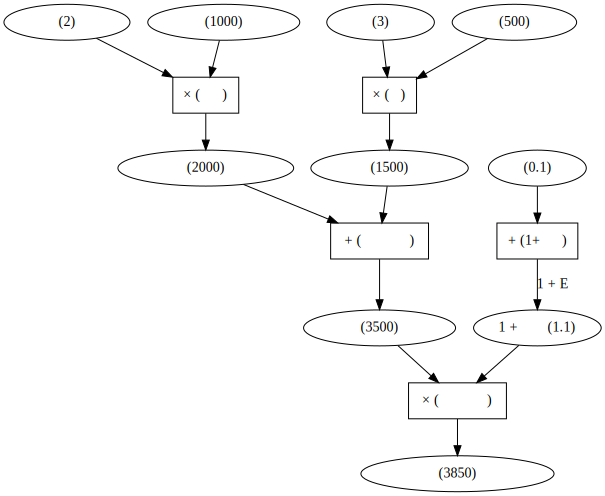

In [ ]:
dot = graphviz.Digraph(comment='Apple and Orange Price Calculation')

# Inputs
dot.node('A', '사과 개수 (2)')
dot.node('B', '사과 단가 (1000)')
dot.node('C', '귤 개수 (3)')
dot.node('D', '귤 단가 (500)')
dot.node('E', '세율 (0.1)')

# Operations
dot.node('M1', '× (사과)', shape='box')
dot.node('M2', '× (귤)', shape='box')
dot.node('A1', '+ (상품 총액)', shape='box')
dot.node('A2', '+ (1+세율)', shape='box')
dot.node('M3', '× (최종 결제)', shape='box')

# Outputs
dot.node('OA', '사과 총 가격 (2000)')
dot.node('OB', '귤 총 가격 (1500)')
dot.node('OC', '상품 총액 (3500)')
dot.node('OD', '1 + 세율 (1.1)')
dot.node('OE', '최종 결제 금액 (3850)')

# Connections
dot.edge('A', 'M1')
dot.edge('B', 'M1')
dot.edge('M1', 'OA')

dot.edge('C', 'M2')
dot.edge('D', 'M2')
dot.edge('M2', 'OB')

dot.edge('OA', 'A1')
dot.edge('OB', 'A1')
dot.edge('A1', 'OC')

dot.edge('E', 'A2')
dot.edge('A2', 'OD', label='1 + E') # Visualizing (1+tax_rate)

dot.edge('OC', 'M3')
dot.edge('OD', 'M3')
dot.edge('M3', 'OE')

display(dot)


#### 🦍 딥러닝에서의 역할 (1):
입력 데이터가 신경망의 여러 층을 통과하며 최종 예측값(예: 이미지 속 고양이 확률)을 만드는 과정이 바로 순전파입니다. 모든 계산은 이 순서대로 이뤄져야 다음 단계로 진행할 수 있습니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
모델이 '이 사진은 고양이일까? 강아지일까?' 판단할 때, 먼저 사진 속의 털 색깔, 귀 모양, 눈 크기 등을 순서대로 확인하며 '고양이 특징 몇 점, 강아지 특징 몇 점' 하는 식으로 점수를 매겨나가는 과정과 같습니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
레스토랑에서 주문을 받으면, '재료 손질 -> 조리 -> 플레이팅'의 단계를 거쳐 음식을 내보내는 것처럼, 딥러닝도 데이터를 받아 순서대로 처리하여 최종 결과물을 내는 방식입니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 순전파 계산 (001)

사과 2개(각 1000원), 귤 3개(각 500원), 소비세 10%를 계산하는 과정을 파이썬으로 표현해볼게요. 각 단계를 순서대로 진행합니다.

In [ ]:
import numpy as np

# 1단계: 사과 가격 계산
apple_price_per_unit = 1000
num_apples = 2
total_apple_cost = apple_price_per_unit * num_apples
print(f"사과 총 가격: {total_apple_cost}원")

# 2단계: 귤 가격 계산
orange_price_per_unit = 500
num_oranges = 3
total_orange_cost = orange_price_per_unit * num_oranges
print(f"귤 총 가격: {total_orange_cost}원")

# 3단계: 전체 상품 가격 합산
subtotal = total_apple_cost + total_orange_cost
print(f"상품 총액 (세금 미포함): {subtotal}원")

# 4단계: 소비세 적용 (소비세 10%)
tax_rate = 0.1
total_cost_with_tax = subtotal * (1 + tax_rate)
print(f"최종 결제 금액 (세금 포함): {int(total_cost_with_tax)}원")

사과 총 가격: 2000원
귤 총 가격: 1500원
상품 총액 (세금 미포함): 3500원
최종 결제 금액 (세금 포함): 3850원


#### 💡 확인 문제: 001. 계산 그래프의 순전파

Q1. 요리 레시피에서 재료가 들어가서 최종 결과물(음식)이 나올 때까지, 각 단계를 순서대로 쭉 따라가며 계산하는 과정을 무엇이라고 하나요?

Q2. 딥러닝에서 입력 데이터가 신경망을 거쳐 최종 예측값을 만드는 과정을 무엇이라고 부르나요?

Q3. 사과와 귤 가격을 각각 계산하고, 합산하고, 세금을 적용하는 것처럼 복잡한 계산을 여러 단계로 나누어 진행하는 방식의 장점은 무엇일까요?

✅ **정답**

Q1. 순전파 (Forward Propagation)

Q2. 순전파 (Forward Propagation)

Q3. 복잡한 계산을 이해하기 쉽고, 각 단계에서 무엇이 일어나는지 명확히 알 수 있습니다. (또는, 오류 발생 시 어느 단계에서 발생했는지 파악하기 용이합니다.)

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>






### 002: Backward Propagation for Addition (덧셈 노드의 역전파)

### 👨‍🍳 요리 레시피 탐구: 덧셈 노드의 역전파 (002)

요리가 완성된 후, 맛을 보고 피드백을 주는 과정(역전파)이 필요해요. 만약 주방장이 '음식이 너무 짜다!'는 피드백을 받았다면, 이 피드백이 각 재료에 어떻게 전달될까요? 특히, 여러 재료를 '더하는' 과정에서는 피드백이 아주 단순하게 전달됩니다. 덧셈은 원래 재료의 맛을 그대로 유지하니까, '짜다'는 피드백도 각 재료에 '똑같이 짜다'고 전달되는 식이죠. 마치 맛 평가(피드백)가 어떤 변형도 없이 재료에 그대로 반영되는 것과 같아요.

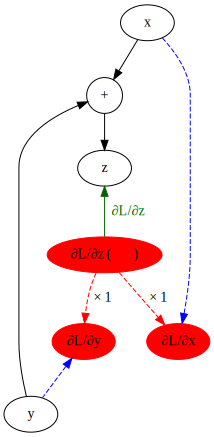

In [ ]:
import graphviz

# 덧셈 노드의 역전파 계산 그래프
dot_add_bp = graphviz.Digraph(comment='Addition Node Backpropagation')

# 노드 정의
# 입력 변수
dot_add_bp.node('x', 'x')
dot_add_bp.node('y', 'y')

# 덧셈 연산 노드
dot_add_bp.node('add_op', '+', shape='circle')

# 출력 변수
dot_add_bp.node('z', 'z')

# 순전파 흐름 (화살표)
dot_add_bp.edge('x', 'add_op')
dot_add_bp.edge('y', 'add_op')
dot_add_bp.edge('add_op', 'z')

# 역전파 기울기 노드
dot_add_bp.node('dL_dz', '∂L/∂z (상류)', color='red', style='filled') # 상류에서 넘어온 기울기
dot_add_bp.node('dL_dx', '∂L/∂x', color='red', style='filled') # x에 대한 기울기
dot_add_bp.node('dL_dy', '∂L/∂y', color='red', style='filled') # y에 대한 기울기

# 역전파 흐름 (빨간색 화살표와 라벨)
# z에서 dL/dz가 넘어옴 (개념적인 표현)
dot_add_bp.edge('z', 'dL_dz', dir='back', label='  ∂L/∂z  ', color='darkgreen', fontcolor='darkgreen')

# dL/dz가 덧셈 노드를 거쳐 dL/dx와 dL/dy로 전달되는 모습
# 덧셈 노드의 미분은 1이므로, 상류 기울기가 그대로 전달됨
dot_add_bp.edge('dL_dz', 'dL_dx', label=' × 1 ', color='red', style='dashed')
dot_add_bp.edge('dL_dz', 'dL_dy', label=' × 1 ', color='red', style='dashed')

# 최종적으로 각 변수에 기울기가 도달함을 나타냄
dot_add_bp.edge('dL_dx', 'x', dir='back', color='blue', style='dashed')
dot_add_bp.edge('dL_dy', 'y', dir='back', color='blue', style='dashed')

display(dot_add_bp)


#### 📊 계산 그래프 시각화: 덧셈 노드의 역전파 (002)

아래 그래프는 `z = x + y`라는 덧셈 연산에서 역전파가 어떻게 일어나는지 보여줍니다. 상류에서 전달된 미분값(기울기, `∂L/∂z`)이 덧셈 노드를 거쳐 하류의 입력값(`x`, `y`)에 대한 미분값(`∂L/∂x`, `∂L/∂y`)으로 **그대로(1을 곱하여)** 전달되는 것을 시각적으로 확인할 수 있습니다. 이는 덧셈 노드의 미분값이 항상 1이기 때문입니다.



*   **수학적 의미**:
$z = x + y \implies \frac{\partial z}{\partial x} = 1, \; \frac{\partial z}{\partial y} = 1$
상류에서 흘러온 미분값($\frac{\partial L}{\partial z}$)에 1을 곱하여 하류($x, y$ 방향)로 그대로 전달합니다. 즉, 입력값의 크기와 상관없이 기울기가 그대로 보존됩니다.
*   **생활 비유**:
“상사에게서 내려온 지시(기울기)를 중간 관리자가 아무런 왜곡이나 가감 없이 팀원들에게 똑같은 강도로 전달하는 투명한 중계자.”
*   **딥러닝 연결**:
신경망에서 편향(bias)을 더하는 연산이나 잔차 연결(Residual Connection) 구조에서 기울기가 죽지 않고 원형 그대로 전파되도록 돕는 역할을 합니다.

#### 🦍 딥러닝에서의 역할 (1):
덧셈 노드는 신경망에서 편향(bias)을 더하거나, 여러 경로에서 온 정보들을 합칠 때 사용됩니다. 역전파 시에는 상류에서 온 기울기(피드백)가 덧셈 노드를 통해 각 입력으로 **그대로 전달**됩니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
팀 프로젝트에서 '더 좋은 아이디어를 내라'는 상사의 지시(기울기)가 오면, 팀원 A와 B가 각자 낸 아이디어를 '더하는' 회의를 했을 경우, 상사의 지시는 팀원 A와 B에게 **동일한 무게로 전달**되는 것과 같습니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
레시피에서 '소금 5g + 후추 2g'처럼 여러 양념을 섞을 때, 나중에 '좀 더 간간하게!'라는 지시가 오면, 소금에도 '좀 더 간간하게!', 후추에도 '좀 더 간간하게!'라고 **똑같이 피드백**하는 것과 같아요. 각 양념 자체의 맛을 바꾸는 것이 아니라, 전체적인 간을 맞추는 피드백은 균등하게 적용되는 거죠.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 덧셈 노드의 역전파 (002)

덧셈 노드를 통과할 때 피드백(기울기)이 어떻게 전달되는지 간단한 함수를 통해 확인해볼게요.

In [ ]:
# 덧셈 함수 정의
def add_func(x, y):
    return x + y

# 순전파: 입력 x=5, y=3
x = 5
y = 3
z = add_func(x, y)
print(f"순전파: {x} + {y} = {z}")

# 역전파: z에 대한 최종 피드백(기울기)이 1이라고 가정
dz = 1 # 상류에서 흘러온 미분값 (피드백)

# 덧셈 노드 역전파 규칙: dz가 dx, dy로 그대로 전달
dx = dz * 1 # dz를 x 방향으로 전달
dy = dz * 1 # dz를 y 방향으로 전달

print(f"역전파: 최종 피드백 {dz}가 x에 {dx}로, y에 {dy}로 전달됩니다.")
print("-> 덧셈 노드에서는 피드백이 변함없이 그대로 전달되는 것을 알 수 있습니다.")

순전파: 5 + 3 = 8
역전파: 최종 피드백 1가 x에 1로, y에 1로 전달됩니다.
-> 덧셈 노드에서는 피드백이 변함없이 그대로 전달되는 것을 알 수 있습니다.


#### 💡 확인 문제: 002. 덧셈 노드의 역전파

Q1. 계산 결과에 대한 피드백(오차)이 덧셈이 일어난 곳으로 돌아갈 때, 이 피드백은 각 입력값들에게 어떻게 전달되나요? (변함없이 똑같이? 아니면 다르게?)

Q2. 딥러닝에서 덧셈 노드는 주로 어떤 값을 더할 때 사용되나요? (힌트: 모델의 기본값)

Q3. 덧셈 노드의 역전파에서 피드백이 변함없이 그대로 전달되는 수학적인 이유(미분값)는 무엇인가요?

✅ **정답**

Q1. 변함없이 똑같이 전달됩니다.

Q2. 편향(bias)을 더하거나, 여러 경로에서 온 정보를 합칠 때 사용됩니다.

Q3. 덧셈 함수의 미분값은 항상 1이기 때문입니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>





### 003: Backward Propagation for Multiplication (곱셈 노드의 역전파)

### 👨‍🍳 요리 레시피 탐구: 곱셈 노드의 역전파 (003)

이번에는 '재료의 양'과 '재료의 맛 강도'를 곱해서 최종 맛을 결정하는 경우를 생각해볼까요? 예를 들어, '향신료 양 * 향신료 강도'처럼요. 만약 요리가 너무 매워서 '매운맛을 줄여라!'는 피드백을 받았다면, 이 피드백은 '향신료 양'과 '향신료 강도' 중 어느 쪽에 더 중요하게 전달되어야 할까요? 놀랍게도, 곱셈에서는 피드백이 **서로 상대방의 값에 비례하여 전달**됩니다. 향신료 양을 조절할 때는 향신료 강도가 중요하고, 향신료 강도를 조절할 때는 향신료 양이 중요하게 작용하는 식이죠. 마치 서로의 역할에 따라 피드백의 크기가 달라지는 것과 같아요.

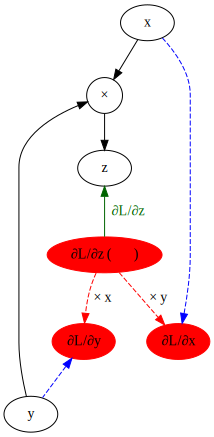

In [ ]:
import graphviz

# 곱셈 노드의 역전파 계산 그래프
dot_mul_bp = graphviz.Digraph(comment='Multiplication Node Backpropagation')

# 노드 정의
# 입력 변수
dot_mul_bp.node('x', 'x', shape='ellipse')
dot_mul_bp.node('y', 'y', shape='ellipse')

# 곱셈 연산 노드
dot_mul_bp.node('mul_op', '×', shape='circle')

# 출력 변수
dot_mul_bp.node('z', 'z', shape='ellipse')

# 순전파 흐름 (화살표)
dot_mul_bp.edge('x', 'mul_op')
dot_mul_bp.edge('y', 'mul_op')
dot_mul_bp.edge('mul_op', 'z')

# 역전파 기울기 노드
dot_mul_bp.node('dL_dz', '∂L/∂z (상류)', color='red', style='filled') # 상류에서 넘어온 기울기
dot_mul_bp.node('dL_dx', '∂L/∂x', color='red', style='filled') # x에 대한 기울기
dot_mul_bp.node('dL_dy', '∂L/∂y', color='red', style='filled') # y에 대한 기울기

# 역전파 흐름 (빨간색 화살표와 라벨)
# z에서 dL/dz가 넘어옴 (개념적인 표현)
dot_mul_bp.edge('z', 'dL_dz', dir='back', label='  ∂L/∂z  ', color='darkgreen', fontcolor='darkgreen')

# dL/dz가 곱셈 노드를 거쳐 dL/dx와 dL/dy로 전달되는 모습
# 곱셈 노드의 미분은 상대방 입력값을 곱함
dot_mul_bp.edge('dL_dz', 'dL_dx', label=' × y ', color='red', style='dashed')
dot_mul_bp.edge('dL_dz', 'dL_dy', label=' × x ', color='red', style='dashed')

# 최종적으로 각 변수에 기울기가 도달함을 나타냄
dot_mul_bp.edge('dL_dx', 'x', dir='back', color='blue', style='dashed')
dot_mul_bp.edge('dL_dy', 'y', dir='back', color='blue', style='dashed')

display(dot_mul_bp)


#### 📊 계산 그래프 시각화: 곱셈 노드의 역전파 (003)

그래프는 `z = x * y`라는 곱셈 연산에서 역전파가 어떻게 일어나는지 보여줍니다. 상류에서 전달된 미분값(기울기, `∂L/∂z`)이 곱셈 노드를 거쳐 하류의 입력값(`x`, `y`)에 대한 미분값(`∂L/∂x`, `∂L/∂y`)으로 전달될 때, **각각 상대방의 순전파 시 입력값에 비례하여** 전달되는 것을 시각적으로 확인할 수 있습니다. 즉, `x` 방향으로는 `y`를 곱하고, `y` 방향으로는 `x`를 곱하게 됩니다.



*   **수학적 의미**:
$z = xy \implies \frac{\partial z}{\partial x} = y, \; \frac{\partial z}{\partial y} = x$
상류에서 흘러온 미분값($\frac{\partial L}{\partial z}$)에 **서로 상대방의 입력값**을 곱하여 하류로 전달합니다. 즉, $x$ 방향으로는 $y$를 곱하고, $y$ 방향으로는 $x$를 곱해 줍니다.
*   **생활 비유**:
“둘이서 동업할 때, 내 기여도에 대한 피드백(기울기)은 내가 아닌 상대방의 몸값(입력값) 크기에 비례해서 결정되는 크로스 구조.”
*   **딥러닝 연결**:
가중치($W$)와 입력 데이터($X$)의 곱으로 이루어진 행렬 연산에서, 역전파 시 가중치의 업데이트 크기가 입력값의 크기에 영향을 받게 되는 수학적 근거가 됩니다.

#### 🦍 딥러닝에서의 역할 (1):
곱셈 노드는 주로 입력 데이터에 가중치(weight)를 곱하는 역할을 합니다. 역전파 시에는 기울기가 입력값에 따라 다르게 전달되므로, 중요도가 높은 입력에 더 큰 영향(기울기)이 전달됩니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
시험 성적에서 '공부 시간 (X) * 집중도 (Y) = 최종 점수 (Z)'라고 가정해봅시다. 만약 최종 점수가 낮아서 '점수를 올려라!'는 피드백(기울기)이 온다면, 집중도(Y)가 높았을 때는 공부 시간(X)을 늘리라는 피드백이 더 크게 전달되고, 공부 시간(X)이 많았을 때는 집중도(Y)를 높이라는 피드백이 더 크게 전달되는 것과 같습니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
요리에서 '재료 A 양 * 재료 B의 맛 강도'로 최종 맛이 결정될 때, '싱겁다'는 피드백이 오면, 재료 A가 많이 들어갔을 때는 '재료 B의 맛 강도를 높여!'라고 하고, 재료 B의 맛이 강했을 때는 '재료 A의 양을 늘려!'라고 하는 것처럼, **상대방의 현재 상태에 따라 피드백의 초점**이 달라지는 것과 같아요.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 곱셈 노드의 역전파 (003)

곱셈 노드를 통과할 때 피드백(기울기)이 어떻게 전달되는지 간단한 함수를 통해 확인해볼게요. 상대방의 입력값에 비례하여 전달되는 것을 볼 수 있습니다.

In [ ]:
# 곱셈 함수 정의
def mul_func(x, y):
    return x * y

# 순전파: 입력 x=4, y=5
x = 4
y = 5
z = mul_func(x, y)
print(f"순전파: {x} * {y} = {z}")

# 역전파: z에 대한 최종 피드백(기울기)이 1이라고 가정
dz = 1 # 상류에서 흘러온 미분값 (피드백)

# 곱셈 노드 역전파 규칙: 서로 상대방의 입력값을 곱하여 전달
dx = dz * y # dz에 y를 곱하여 x 방향으로 전달
dy = dz * x # dz에 x를 곱하여 y 방향으로 전달

print(f"역전파: 최종 피드백 {dz}가 x에 {dx}로, y에 {dy}로 전달됩니다.")
print("-> 곱셈 노드에서는 피드백이 상대방 입력값에 따라 다르게 전달되는 것을 알 수 있습니다.")

순전파: 4 * 5 = 20
역전파: 최종 피드백 1가 x에 5로, y에 4로 전달됩니다.
-> 곱셈 노드에서는 피드백이 상대방 입력값에 따라 다르게 전달되는 것을 알 수 있습니다.


#### 💡 확인 문제: 003. 곱셈 노드의 역전파

Q1. 계산 결과에 대한 피드백(오차)이 곱셈이 일어난 곳으로 돌아갈 때, 이 피드백은 각 입력값들에게 어떻게 전달되나요?

Q2. 딥러닝에서 곱셈 노드는 주로 어떤 역할(데이터와 무엇을 곱하는지)을 하나요?

Q3. 곱셈 노드의 역전파에서 피드백이 '서로 상대방의 값에 비례하여' 전달되는 현상이 딥러닝 학습에 어떤 이점을 주나요?

✅ **정답**

Q1. 서로 상대방의 값에 비례하여 전달됩니다.

Q2. 입력 데이터에 가중치(weight)를 곱하는 역할을 합니다.

Q3. 중요도가 높은 입력에 더 큰 영향(기울기)이 전달되어 모델이 더욱 정교하게 학습할 수 있습니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>





### 004: Gradient for Batch Affine Layer (배치용 Affine 계층의 편미분)

### 👨‍🍳 요리 레시피 탐구: 배치용 Affine 계층의 편미분 (004)

우리 레스토랑이 바쁠 때는 한 번에 여러 손님을 위한 수십 그릇의 같은 요리를 준비해요. 이럴 때, 각 요리의 맛을 일일이 조절하는 건 비효율적이겠죠? 딥러닝에서도 데이터를 하나씩 처리하는 대신, 여러 데이터를 '묶음'(Batch)으로 처리합니다. Affine 계층에서는 이 묶음 데이터를 효율적으로 처리하기 위해 '재료'와 '맛'의 영향력을 행렬이라는 큰 표를 이용해 계산하고, 피드백(미분) 역시 이 큰 표를 뒤집거나 조합해서 한 번에 여러 요리의 맛을 조절할 수 있도록 합니다. 대량 생산에 최적화된 요리 조절법이라고 할 수 있죠.

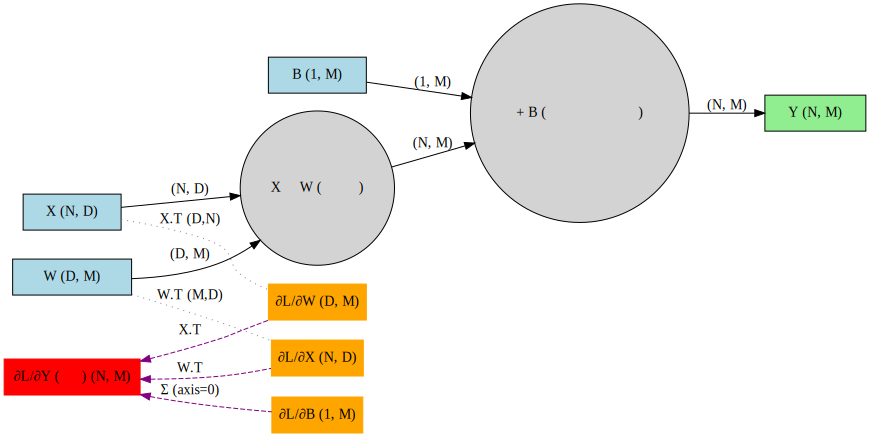

In [ ]:
import graphviz

# 배치용 Affine 계층의 순/역전파 계산 그래프
dot_affine_bp = graphviz.Digraph(comment='Batch Affine Layer Backpropagation')

dot_affine_bp.attr(rankdir='LR') # Left to Right layout

# 순전파 노드
dot_affine_bp.node('X', '입력 X (N, D)', shape='box', style='filled', fillcolor='lightblue')
dot_affine_bp.node('W', '가중치 W (D, M)', shape='box', style='filled', fillcolor='lightblue')
dot_affine_bp.node('B', '편향 B (1, M)', shape='box', style='filled', fillcolor='lightblue')

dot_affine_bp.node('mul_op', 'X ⋅ W (행렬 곱)', shape='circle', style='filled', fillcolor='lightgray')
dot_affine_bp.node('add_op', '+ B (브로드캐스트 덧셈)', shape='circle', style='filled', fillcolor='lightgray')

dot_affine_bp.node('Y', '출력 Y (N, M)', shape='box', style='filled', fillcolor='lightgreen')

# 순전파 연결
dot_affine_bp.edge('X', 'mul_op', label='(N, D)')
dot_affine_bp.edge('W', 'mul_op', label='(D, M)')
dot_affine_bp.edge('mul_op', 'add_op', label='(N, M)')
dot_affine_bp.edge('B', 'add_op', label='(1, M)')
dot_affine_bp.edge('add_op', 'Y', label='(N, M)')

# 역전파 노드 (기울기)
dot_affine_bp.node('dL_dY', '∂L/∂Y (상류) (N, M)', shape='box', color='red', style='filled')
dot_affine_bp.node('dL_dX', '∂L/∂X (N, D)', shape='box', color='orange', style='filled')
dot_affine_bp.node('dL_dW', '∂L/∂W (D, M)', shape='box', color='orange', style='filled')
dot_affine_bp.node('dL_dB', '∂L/∂B (1, M)', shape='box', color='orange', style='filled')

# 역전파 연결
# dL/dY -> dL/dB (합산)
dot_affine_bp.edge('dL_dY', 'dL_dB', label='Σ (axis=0)', dir='back', color='purple', style='dashed')

# dL/dY -> dL/dX (dL/dY ⋅ W.T)
dot_affine_bp.edge('dL_dY', 'dL_dX', label='⋅ W.T', dir='back', color='purple', style='dashed')
dot_affine_bp.edge('W', 'dL_dX', label='W.T (M,D)', dir='none', color='gray', style='dotted') # W의 전치가 필요함을 나타냄

# dL/dY -> dL/dW (X.T ⋅ dL/dY)
dot_affine_bp.edge('dL_dY', 'dL_dW', label='X.T ⋅', dir='back', color='purple', style='dashed')
dot_affine_bp.edge('X', 'dL_dW', label='X.T (D,N)', dir='none', color='gray', style='dotted') # X의 전치가 필요함을 나타냄

display(dot_affine_bp)


#### 📊 계산 그래프 시각화: 배치용 Affine 계층의 순/역전파 (004)

그래프는 배치(Batch) 단위로 처리되는 Affine 계층(`Y = XW + B`)의 순전파와 역전파 과정을 시각적으로 보여줍니다.

**순전파:** 입력 데이터 행렬 `X`와 가중치 행렬 `W`가 곱해지고(`XW`), 여기에 편향 `B`가 더해져 최종 출력 `Y`가 계산되는 흐름입니다.

**역전파:** 상류에서 전달된 미분값(`∂L/∂Y`)이 `X`, `W`, `B`에 대한 미분값(`∂L/∂X`, `∂L/∂W`, `∂L/∂B`)으로 어떻게 역전파되는지 보여줍니다. 특히, 행렬 곱셈의 역전파는 전치 행렬(`W.T`, `X.T`)과의 곱셈을 통해 이루어지며, 편향 `B`의 기울기는 `∂L/∂Y`의 각 행을 합산하여 구해지는 것을 볼 수 있습니다.



*   **수학적 의미**:
* $\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} \cdot W^T \quad \text{(N, 2) = (N, 3) $\cdot$ (3, 2)}$
* $\frac{\partial L}{\partial W} = X^T \cdot \frac{\partial L}{\partial Y} \quad \text{(2, 3) = (2, N) $\cdot$ (N, 3)}$
* $\frac{\partial L}{\partial B} = \text{axis=0 방향으로 } \frac{\partial L}{\partial Y} \text{의 합}


*   **생활 비유**:
“대규모 인원의 성적표 행렬을 다룰 때, 개별 점수와 과목별 가중치의 영향력을 역추적하기 위해 행렬을 뒤집고(전치) 묶어서 덤핑으로 계산하는 방식.”
*   **딥러닝 연결**:
하나의 데이터가 아닌 묶음 데이터(Batch)가 흘러갈 때, 다차원 행렬의 차원(Shape)을 일치시키면서 모든 매개변수의 기울기를 효율적으로 계산하는 실제 딥러닝 프레임워크의 핵심 연산입니다.

#### 🦍 딥러닝에서의 역할 (1):
Affine 계층은 신경망의 '완전 연결층(Fully Connected Layer)'에 해당하며, 입력 데이터를 가중치와 곱하고 편향을 더하는 핵심 연산입니다. 배치(Batch) 단위로 데이터를 처리하여 학습 효율을 높입니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
학교에서 시험지를 채점할 때, 학생 한 명 한 명의 답안지를 따로 보는 게 아니라, '한 반의 시험지 묶음(Batch)'을 통째로 채점해서 각 학생(입력)의 정답률(Y)과 채점 기준(W)을 한 번에 평가하고, '평균적으로 어떤 부분이 틀렸는지' 피드백(기울기)을 주는 것과 같습니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
공장에서 자동차를 여러 대 만들 때, 각 부품(X)과 조립 매뉴얼(W)을 행렬처럼 구성하여 '차량 1대에 대한 조립 공정'을 여러 차량에 동시에 적용하여 생산 속도를 높이는 과정과 같습니다. 문제가 생기면 어떤 부품(X)이나 매뉴얼(W)에 문제가 있었는지 일괄적으로 찾아냅니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 배치용 Affine 계층의 연산 (004)

여러 데이터(배치)를 한 번에 처리하는 Affine 계층의 순전파 연산을 NumPy를 이용해 살펴볼게요.

In [ ]:
# 배치 입력 데이터 (3개의 데이터, 각 데이터는 2가지 특징)
X = np.array([[1, 2], [3, 4], [5, 6]])
print("입력 데이터 X (3x2):")
print(X)

# 가중치 (2가지 특징을 3가지 출력으로 변환)
W = np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]])
print("\n가중치 W (2x3):")
print(W)

# 편향 (출력 특징 수와 동일)
B = np.array([0.1, 0.2, 0.3])
print("\n편향 B (1x3):")
print(B)

# 순전파 연산: Y = XW + B
Y = np.dot(X, W) + B
print("\n출력 Y (3x3):")
print(Y)

print("-> 여러 데이터를 한 번에 행렬 연산으로 처리하여 효율적인 계산이 가능합니다.")

입력 데이터 X (3x2):
[[1 2]
 [3 4]
 [5 6]]

가중치 W (2x3):
[[0.1 0.2 0.3]
 [0.4 0.5 0.6]]

편향 B (1x3):
[0.1 0.2 0.3]

출력 Y (3x3):
[[1.  1.4 1.8]
 [2.  2.8 3.6]
 [3.  4.2 5.4]]
-> 여러 데이터를 한 번에 행렬 연산으로 처리하여 효율적인 계산이 가능합니다.


#### 💡 확인 문제: 004. 배치용 Affine 계층의 편미분

Q1. 딥러닝에서 데이터를 하나씩 처리하는 대신, 여러 데이터를 '묶음'으로 처리하는 것을 무엇이라고 부르나요?

Q2. Affine 계층에서 이 묶음 데이터를 효율적으로 처리하기 위해 '재료'와 '맛'의 영향력을 계산할 때 사용하는 수학적 도구는 무엇인가요?

Q3. 배치(Batch) 단위로 데이터를 처리하는 것이 딥러닝 모델 학습에 어떤 이점을 제공하나요?

✅ **정답**

Q1. 배치(Batch)

Q2. 행렬 (Matrix)

Q3. 학습 효율을 높이고, 계산을 빠르게 하며, 안정적인 학습을 돕습니다.

<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>

### 005: Python Implementation of ReLU Layer (ReLU 계층 구현)


### 👨‍🍳 요리 레시피 탐구: ReLU 계층 구현 (005)

요리에는 '최소한의 기준'이 있기 마련이죠. 예를 들어, 어떤 재료의 맛이 일정 수준(0) 이하라면, 그 재료는 아예 사용하지 않거나, 그 맛을 0으로 쳐서 요리에 영향을 주지 않게 하는 거예요. ReLU(렐루) 계층은 딱 그 역할을 합니다. 재료의 맛이 0 이하면 '무시!'하고, 0보다 크면 '사용!'하는 거죠. 그리고 나중에 맛에 대한 피드백(역전파)이 올 때는, 애초에 무시했던 재료에 대해서는 아무런 피드백도 주지 않아요. 마치 '쓸모없는 재료는 아예 신경도 쓰지 않는' 현명한 주방장의 모습과 같아요.



*   **수학적/코드 구조**:
순전파 시 입력 $x \le 0$인 위치를 `self.mask`에 기록하고 0으로 뭉갭니다. 역전파(`backward`) 때는 마스크를 활용해 순전파 때 0 이하인 자리는 미분값도 0으로 만들고, 0보다 컸던 자리는 상류의 미분(`dout`)을 그대로 통과시킵니다.
*   **생활 비유**:
“입장할 때 불합격 기준(0 이하)을 만족한 블랙리스트 명단을 적어두었다가, 퇴장할 때 그 사람들에게만 보상금지(기울기 0) 처리를 하는 시스템.”
*   **딥러닝 연결**:
기울기 소실을 방지하는 ReLU 활성화 함수가 역전파 때 어떻게 특정 뉴런의 신호를 차단하거나 통과시키는지 코드로 명확히 보여줍니다.

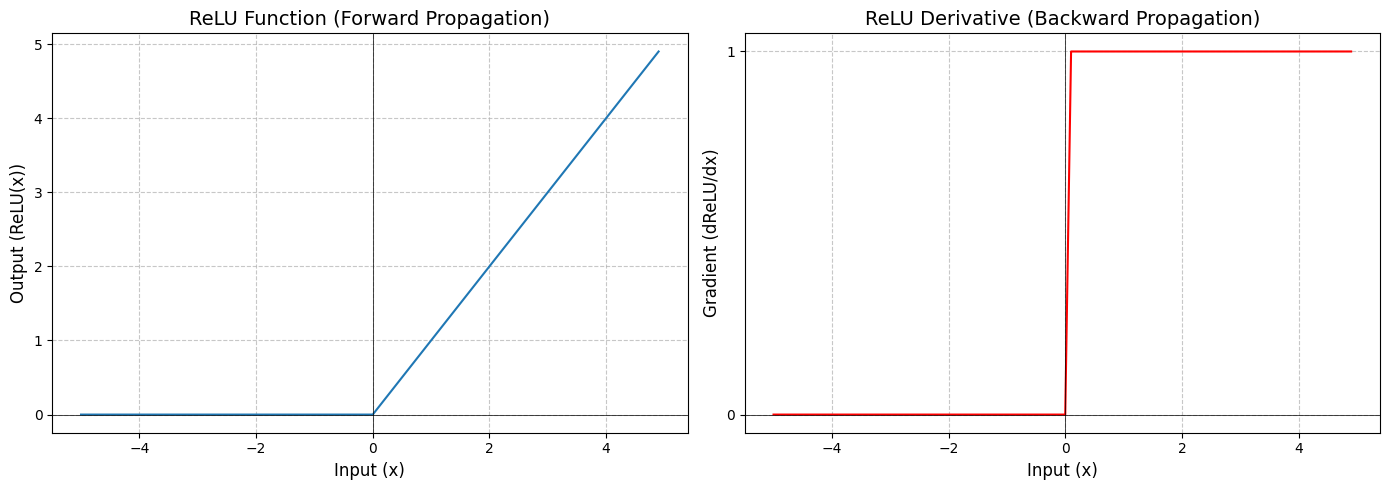

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ReLU 함수 정의
def relu_func(x):
    return np.maximum(0, x)

# ReLU 함수의 미분 정의 (역전파 시 사용)
def relu_grad(x):
    grad = (x > 0).astype(np.float32)
    return grad

# 입력 값 범위 설정
x = np.arange(-5.0, 5.0, 0.1)
y = relu_func(x)
grad = relu_grad(x)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 순전파 (ReLU 함수) 그래프
ax1.plot(x, y)
ax1.set_title('ReLU Function (Forward Propagation)', fontsize=14)
ax1.set_xlabel('Input (x)', fontsize=12)
ax1.set_ylabel('Output (ReLU(x))', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(0, color='black',linewidth=0.5)
ax1.axvline(0, color='black',linewidth=0.5)
ax1.tick_params(axis='both', which='major', labelsize=10)

# 역전파 (ReLU 미분) 그래프
ax2.plot(x, grad, color='red')
ax2.set_title('ReLU Derivative (Backward Propagation)', fontsize=14)
ax2.set_xlabel('Input (x)', fontsize=12)
ax2.set_ylabel('Gradient (dReLU/dx)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(0, color='black',linewidth=0.5)
ax2.axvline(0, color='black',linewidth=0.5)
ax2.tick_params(axis='both', which='major', labelsize=10)
ax2.set_yticks([0, 1]) # 미분값이 0 또는 1임을 명확히 보여줌

plt.tight_layout()
plt.show()

#### 📊 함수 그래프 시각화: ReLU 계층의 순전파와 역전파 (005)

그래프는 ReLU(Rectified Linear Unit) 활성화 함수의 특징을 보여줍니다.

*   **ReLU 함수 (순전파)**: 입력($x$)이 0보다 작거나 같으면 0을 출력하고, 0보다 크면 입력값을 그대로 출력합니다. 이는 신경망에 비선형성을 부여하여 복잡한 패턴을 학습하게 돕습니다.

*   **ReLU 함수의 미분 (역전파)**: 입력($x$)이 0보다 작거나 같으면 미분값이 0이 되어 해당 뉴런의 기울기를 차단하고, 0보다 크면 미분값이 1이 되어 상류의 기울기를 그대로 통과시킵니다. 이는 '기울기 소실' 문제를 완화하는 데 중요한 역할을 합니다.

#### 🦍 딥러닝에서의 역할 (1):
ReLU는 인공 신경망에서 가장 널리 사용되는 활성화 함수 중 하나입니다. 음수 값을 0으로 만들어 신경망의 비선형성을 부여하고, 기울기 소실 문제를 완화하여 학습을 빠르게 돕습니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
레스토랑의 셰프가 '이 재료의 맛은 0점 이하면 아예 맛으로 치지 마!' 하고 엄격하게 규칙을 정하는 것과 같습니다. 좋은 맛만 골라서 다음 요리 과정에 넘기고, 나쁜 맛은 완전히 무시하는 거죠.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
어떤 정보(신호)가 들어왔을 때, '쓸모없는 정보(음수)'는 과감히 버리고 '쓸모 있는 정보(양수)'만 다음 단계로 넘겨서, 불필요한 계산을 줄이고 중요한 정보에 집중하게 하는 필터링 시스템과 같아요.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: ReLU 활성화 함수 (005)

ReLU 함수가 음수 값을 0으로 만들고 양수 값은 그대로 통과시키는 것을 파이썬 코드로 확인해볼게요.

In [ ]:
# ReLU 함수 정의
def relu(x):
    return np.maximum(0, x)

# 다양한 입력 값
input_values = np.array([-2, -1, 0, 1, 2])

# ReLU 적용
output_values = relu(input_values)

print(f"입력 값: {input_values}")
print(f"ReLU 출력: {output_values}")
print("-> 음수 값은 0이 되고, 양수 값은 그대로 유지되는 것을 볼 수 있습니다.")

# 역전파 시 마스크 개념 (간단화)
# 순전파 때 음수였던 자리는 나중에 피드백이 와도 0으로 차단합니다.
mask = (input_values <= 0) # 0 이하였던 위치는 True, 아니면 False
print(f"\n마스크 (0 이하였던 위치): {mask}")

dout = np.array([0.5, 0.5, 0.5, 0.5, 0.5]) # 상류에서 온 피드백
dx = dout.copy()
dx[mask] = 0 # 마스크된 위치의 피드백은 0으로 만듭니다.
print(f"역전파 (마스크 적용 후 피드백): {dx}")
print("-> 0 이하였던 입력에 대한 피드백은 0으로 차단됩니다.")

입력 값: [-2 -1  0  1  2]
ReLU 출력: [0 0 0 1 2]
-> 음수 값은 0이 되고, 양수 값은 그대로 유지되는 것을 볼 수 있습니다.

마스크 (0 이하였던 위치): [ True  True  True False False]
역전파 (마스크 적용 후 피드백): [0.  0.  0.  0.5 0.5]
-> 0 이하였던 입력에 대한 피드백은 0으로 차단됩니다.


#### 💡 확인 문제: 005. ReLU 계층 구현

Q1. ReLU 계층은 입력 값이 0보다 작거나 같으면 어떤 값으로 만들고, 0보다 크면 어떻게 처리하나요?

Q2. 딥러닝에서 ReLU와 같은 활성화 함수를 사용하는 주된 목적 중 하나는 신경망에 어떤 특성을 부여하는 것인가요?

Q3. ReLU 계층의 역전파에서, 순전파 때 0 이하였던 입력에 대한 피드백이 0으로 차단되는 이유는 무엇인가요?

✅ **정답**

Q1. 0보다 작거나 같으면 0으로 만들고, 0보다 크면 그대로 통과시킵니다.

Q2. 비선형성 (Non-linearity)을 부여하여 복잡한 패턴을 학습할 수 있게 합니다.

Q3. 해당 입력은 순전파 때 아무런 정보를 전달하지 않았으므로, 역전파 때도 그 부분에 대한 피드백은 의미가 없기 때문입니다. (또는, 기울기 소실 방지)

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>



### 006: Python Implementation of Sigmoid Layer (시그모이드 계층 구현)

### 👨‍🍳 요리 레시피 탐구: 시그모이드 계층 구현 (006)

우리 레스토랑의 특별한 '맛 감별기'는 어떤 재료의 맛이든 0과 1 사이의 '확률'로 표현해 줍니다. 예를 들어, '이 재료는 매운맛을 0.8의 강도로 낼 것이다'처럼요. 시그모이드(Sigmoid) 계층은 이런 역할을 하는데, 신기하게도 이 맛 감별기가 내놓은 '확률 값'만 있으면, 나중에 '얼마나 조절해야 할지'에 대한 피드백(미분)을 아주 간단한 공식으로 계산해낼 수 있어요. 마치 맛 감별기 자체에 피드백 계산 공식이 내장되어 있는 것과 같아요.

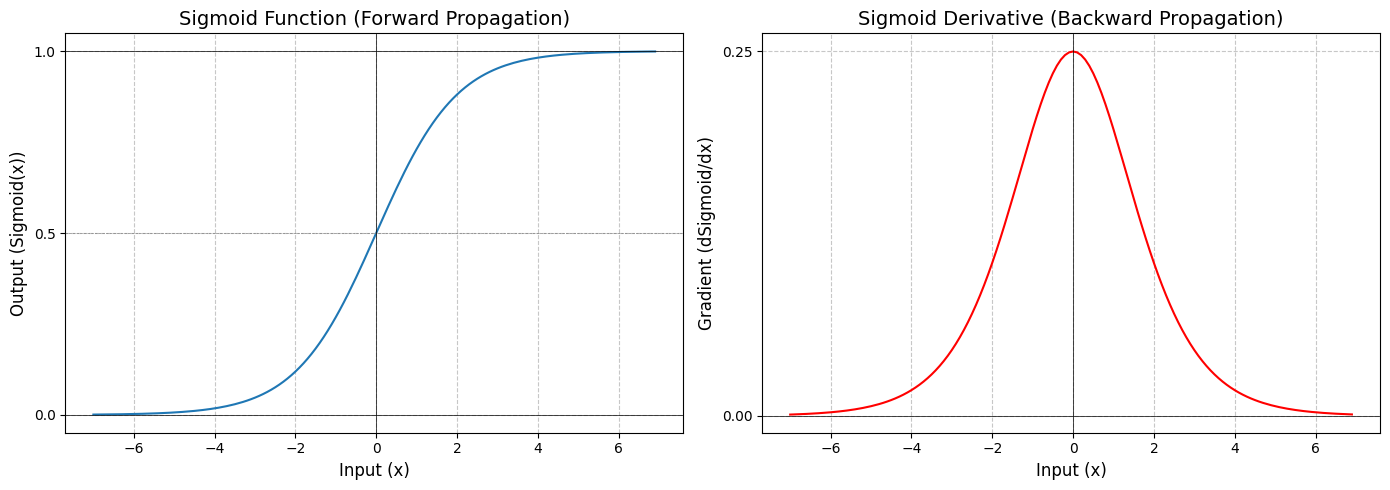

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 시그모이드 함수 정의
def sigmoid_func(x):
    return 1 / (1 + np.exp(-x))

# 시그모이드 함수의 미분 정의 (역전파 시 사용)
def sigmoid_grad(x):
    y = sigmoid_func(x)
    return y * (1 - y)

# 입력 값 범위 설정
x = np.arange(-7.0, 7.0, 0.1)
y = sigmoid_func(x)
grad = sigmoid_grad(x)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 순전파 (Sigmoid 함수) 그래프
ax1.plot(x, y)
ax1.set_title('Sigmoid Function (Forward Propagation)', fontsize=14)
ax1.set_xlabel('Input (x)', fontsize=12)
ax1.set_ylabel('Output (Sigmoid(x))', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(0, color='black',linewidth=0.5)
ax1.axhline(0.5, color='gray',linewidth=0.5, linestyle='--')
ax1.axhline(1, color='black',linewidth=0.5)
ax1.axvline(0, color='black',linewidth=0.5)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.set_yticks([0, 0.5, 1])

# 역전파 (Sigmoid 미분) 그래프
ax2.plot(x, grad, color='red')
ax2.set_title('Sigmoid Derivative (Backward Propagation)', fontsize=14)
ax2.set_xlabel('Input (x)', fontsize=12)
ax2.set_ylabel('Gradient (dSigmoid/dx)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(0, color='black',linewidth=0.5)
ax2.axvline(0, color='black',linewidth=0.5)
ax2.tick_params(axis='both', which='major', labelsize=10)
ax2.set_yticks([0, 0.25]) # 최대 미분값 0.25를 표시

plt.tight_layout()
plt.show()

#### 📊 함수 그래프 시각화: 시그모이드 계층의 순전파와 역전파 (006)

 그래프는 시그모이드(Sigmoid) 활성화 함수의 특징을 보여줍니다.

*   **시그모이드 함수 (순전파)**: 입력($x$)이 어떤 값이든 0과 1 사이의 값으로 변환합니다. 이는 주로 확률을 표현하거나 이진 분류의 출력층에서 사용됩니다.

*   **시그모이드 함수의 미분 (역전파)**: 시그모이드 함수의 미분값은 출력값($y$)을 이용하여 $y(1-y)$로 계산됩니다. 이 미분값은 입력이 0에 가까울수록(그래프 중앙 부분) 커지고, 입력이 양 또는 음의 무한대로 갈수록 0에 수렴하는 특징을 가집니다. 이는 기울기 소실 문제와 연관됩니다.



*   **수학적/코드 구조**:
$\frac{\partial y}{\partial x} = y(1 - y)$ 수식을 코드로 녹여냈습니다. 순전파 출력값 `self.out`($y$)을 저장해 두었다가, 역전파 연산 시 `dout * (1.0 - self.out) * self.out`으로 미분값을 한 번에 계산합니다.
*   **생활 비유**:
“최종 합격률($y$) 정보만 주어지면 복잡한 미분 공식 필요 없이 $y(1-y)$라는 간단한 황금 비율 공식으로 기여도를 뚝딱 계산해 내는 단축키.”
*   **딥러닝 연결**:
시그모이드의 미분값은 항상 순전파의 출력값만으로 재구성할 수 있어, 역전파 계산 효율을 극대화하는 딥러닝의 최적화 기법 중 하나입니다.

#### 🦍 딥러닝에서의 역할 (1):
시그모이드 함수는 주로 이진 분류 문제(예: 고양이 vs 개)의 출력층이나, 각 뉴런의 활성화 정도를 0과 1 사이의 확률 값으로 표현할 때 사용됩니다. 역전파 시에는 출력값을 통해 효율적으로 기울기를 계산할 수 있습니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
의사가 환자의 증상들을 종합해서 '감기일 확률이 0.7(70%)이야' 또는 '독감일 확률이 0.2(20%)야'와 같이 0과 1 사이의 값으로 예측하는 것과 같습니다. 이렇게 나온 확률만 알면, '어떤 증상이 이 확률에 얼마나 영향을 미쳤을까?'를 쉽게 되짚어 볼 수 있어요.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
날씨 예보 시스템에서 '내일 비 올 확률이 0.6(60%)이야'라고 예측하는 것처럼, 어떤 사건이 일어날 가능성을 수치로 알려주는 역할을 합니다. 예측이 틀렸을 때, '어떤 날씨 요소가 이 예측에 가장 큰 영향을 주었을까?'를 파악하는 데도 유용하게 사용됩니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 시그모이드 활성화 함수 (006)

시그모이드 함수가 어떤 값이든 0과 1 사이의 확률 값으로 변환하는 것을 파이썬 코드로 확인해볼게요.

In [ ]:
# 시그모이드 함수 정의
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 다양한 입력 값
input_values = np.array([-5, -1, 0, 1, 5])

# 시그모이드 적용
output_values = sigmoid(input_values)

print(f"입력 값: {input_values}")
print(f"시그모이드 출력: {output_values}")
print("-> 모든 입력 값이 0과 1 사이의 값으로 변환되는 것을 볼 수 있습니다.")

# 시그모이드의 역전파 (dout * y * (1-y)) 예시
y_output = output_values # 순전파 출력값을 y로 가정
dout = np.array([0.1, 0.1, 0.1, 0.1, 0.1]) # 상류에서 온 피드백

dx_sigmoid = dout * y_output * (1 - y_output)
print(f"\n시그모이드 역전파 (기울기): {dx_sigmoid}")
print("-> 출력값(y)만으로 역전파 기울기를 간단히 계산할 수 있습니다.")

입력 값: [-5 -1  0  1  5]
시그모이드 출력: [0.00669285 0.26894142 0.5        0.73105858 0.99330715]
-> 모든 입력 값이 0과 1 사이의 값으로 변환되는 것을 볼 수 있습니다.

시그모이드 역전파 (기울기): [0.00066481 0.01966119 0.025      0.01966119 0.00066481]
-> 출력값(y)만으로 역전파 기울기를 간단히 계산할 수 있습니다.


#### 💡 확인 문제: 006. 시그모이드 계층 구현

Q1. 시그모이드 계층은 어떤 숫자든 몇과 몇 사이의 값으로 바꿔주는 역할을 하나요?

Q2. 딥러닝에서 시그모이드 함수는 주로 어떤 문제의 출력층이나 각 뉴런의 활성화 정도를 표현할 때 사용되나요?

Q3. 시그모이드 함수의 역전파에서, 최종 피드백(기울기)을 계산할 때 사용되는 핵심 정보는 무엇인가요?

✅ **정답**

Q1. 0과 1 사이의 값으로 바꿔줍니다.

Q2. 이진 분류 문제 (Binary Classification)

Q3. 순전파의 출력값(y) (y * (1 - y) 형태)

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>



### 007: Python Implementation of Softmax with Loss Layer (Softmax-with-Loss 계층)


### 👨‍🍳 요리 레시피 탐구: Softmax with Loss 계층 (007)

최종 요리가 완성되면, 이 요리가 어떤 종류(예: 한식, 양식, 일식)인지 '확률'로 예측하고, 동시에 실제 요리 종류와 얼마나 차이가 나는지 '오차'(Loss)를 계산해야 해요. Softmax with Loss 계층은 이 두 가지 일을 한 번에 해줍니다. 마치 요리 품평회에서 '이 요리는 한식일 확률 70%, 양식일 확률 20%...'라고 평가하고, 동시에 '실제와 얼마나 다른가?'를 바로 알려주는 심사위원 같아요. 심지어 나중에 피드백(역전파)을 줄 때는, 복잡한 계산 없이 '예측한 확률과 실제 차이'만큼만 아주 깔끔하게 알려준답니다!

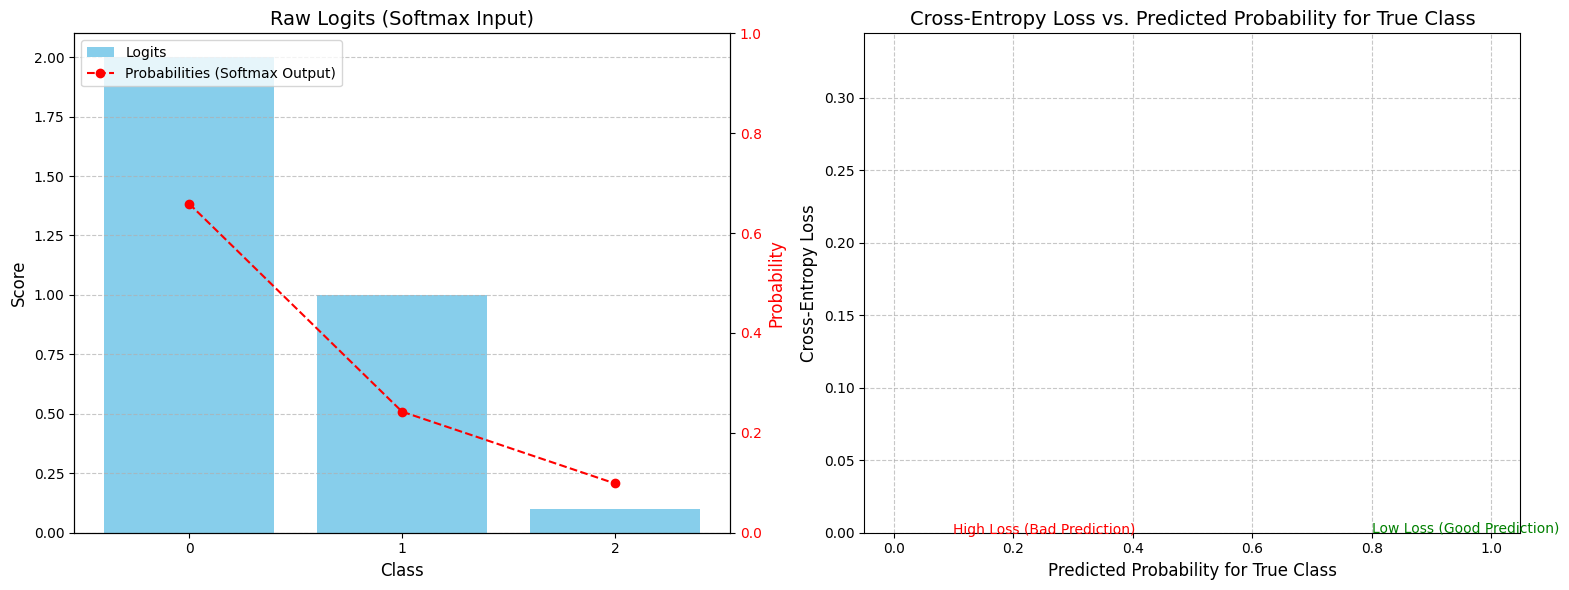

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Softmax 함수 정의
def softmax_func(x):
    e_x = np.exp(x - np.max(x)) # 오버플로우 방지를 위한 트릭
    return e_x / e_x.sum(axis=0)

# 교차 엔트로피 오차 함수 정의 (단일 샘플, 원-핫 인코딩)
def cross_entropy_error_func(y, t):
    delta = 1e-7 # log(0) 방지
    return -np.sum(t * np.log(y + delta))

# --- Softmax 예시 시각화 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 임의의 로짓 값
logits = np.array([2.0, 1.0, 0.1])
probs = softmax_func(logits)

ax1.bar(np.arange(len(logits)), logits, color='skyblue', label='Logits')
ax1.set_title('Raw Logits (Softmax Input)', fontsize=14)
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_xticks(np.arange(len(logits)))
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax1_twin = ax1.twinx() # 두 번째 y축 생성
ax1_twin.plot(np.arange(len(probs)), probs, marker='o', color='red', linestyle='--', label='Probabilities (Softmax Output)')
ax1_twin.set_ylabel('Probability', color='red', fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1_twin.set_ylim(0, 1)

# 범례 병합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_twin.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')

# --- Cross-Entropy Loss 시각화 ---
# 정답 클래스에 대한 예측 확률 범위 (0에 가까우면 매우 틀림, 1에 가까우면 매우 맞음)
p_true = np.linspace(0.001, 0.999, 100) # 0과 1 포함하지 않음 (log(0) 방지)

# 바이너리 분류 가정: 정답은 첫 번째 클래스 (원-핫: [1, 0])
# y: [p_true, 1-p_true]
# t: [1, 0]
losses = [-cross_entropy_error_func(np.array([val, 1-val]), np.array([1, 0])) for val in p_true]

ax2.plot(p_true, losses, color='purple')
ax2.set_title('Cross-Entropy Loss vs. Predicted Probability for True Class', fontsize=14)
ax2.set_xlabel('Predicted Probability for True Class', fontsize=12)
ax2.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_ylim(bottom=0) # Loss는 0보다 작을 수 없음
ax2.text(0.1, np.max(losses)*0.7, 'High Loss (Bad Prediction)', color='red', fontsize=10)
ax2.text(0.8, np.max(losses)*0.1, 'Low Loss (Good Prediction)', color='green', fontsize=10)

plt.tight_layout()
plt.show()

#### 📊 함수 그래프 시각화: Softmax & 교차 엔트로피 오차 (007)

그래프는 Softmax 함수와 Cross-Entropy Loss(교차 엔트로피 오차)의 특징을 보여줍니다.

*   **Softmax 함수**: 모델의 최종 출력값(로짓)을 0과 1 사이의 확률값으로 변환하며, 모든 클래스의 확률을 합하면 1이 됩니다. 주로 다중 클래스 분류 문제의 출력층에서 사용됩니다.

*   **교차 엔트로피 오차**: 모델의 예측 확률이 실제 정답 분포와 얼마나 다른지 측정하는 손실 함수입니다. 정답 클래스에 대한 예측 확률이 낮을수록(모델이 오답을 강하게 예측할수록) 손실 값이 기하급수적으로 커지는 특징을 가집니다. 이는 모델이 정답을 정확하게 예측하도록 강력하게 학습을 유도합니다.


*   **수학적/코드 구조**:
소프트맥스 함수와 교차 엔트로피 오차(Cross Entropy Error)를 하나의 계층으로 묶어 구현했습니다. 역전파 시 복잡한 미분 과정을 거치면 결국 **(예측 확률 $y$ - 정답 레이블 $t$) / 배치 크기**라는 매우 깔끔한 오차 형태로 도출됩니다.
*   **생활 비유**:
“모든 시험 점수를 확률 백분율로 바꾸고 정답지와 비교한 뒤, 역전파 때는 단순하게 ‘내가 예측한 확률과 실제 정답과의 차이’만큼만 피드백하는 깔끔한 정산소.”
*   **딥러닝 연결**:
다중 클래스 분류 문제의 출력층에서 널리 쓰이며, 수학적으로 두 함수를 결합했을 때 미분 형태가 기가 막히게 단순해지는 성질을 이용해 학습 속도와 안정성을 높입니다.

#### 🦍 딥러닝에서의 역할 (1):
Softmax with Loss 계층은 다중 클래스 분류 문제(예: 고양이, 개, 새 중 하나로 분류)에서 사용됩니다. Softmax로 각 클래스에 속할 확률을 계산하고, Cross Entropy Loss로 이 확률과 실제 정답의 차이를 측정하여 모델이 학습할 수 있도록 오차(Loss)를 제공합니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리 경연대회에서 참가 요리가 '한식, 중식, 양식' 중 어떤 장르에 속하는지 심사위원이 확률로 평가하고(Softmax), 동시에 '이 요리는 실제로는 한식인데, 왜 중식으로 예측했지?' 하고 벌점(Loss)을 매기는 것과 같아요. 벌점을 통해 다음 경연에서는 더 정확하게 판단하도록 배우는 거죠.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
마트에서 과일을 스캔할 때, 스캐너가 '이건 사과일 확률 80%, 배일 확률 15%, 귤일 확률 5%'처럼 모든 가능한 과일의 확률을 알려주고(Softmax), 만약 '이건 사과인데 엉뚱하게 배라고 예측했네!' 하고 기계 스스로 오차를 인식하여 다음에는 더 잘 인식하도록 학습하는 시스템과 같습니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: Softmax와 오차 계산 (007)

Softmax 함수로 여러 클래스에 대한 확률을 계산하고, 실제 정답과의 오차(Cross Entropy Error)를 계산하는 과정을 파이썬으로 확인해볼게요.

In [ ]:
# Softmax 함수 정의
def softmax(a):
    c = np.max(a) # 오버플로우 방지 (선택적)
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

# 교차 엔트로피 오차 함수 정의 (이전 섹션에서 자세히 다룸)
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 정답 레이블이 원-핫 인코딩이 아닌 경우 (숫자 레이블)
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    delta = 1e-7 # log(0) 방지
    return -np.sum(np.log(y[np.arange(batch_size), t] + delta)) / batch_size

# 입력 값 (예: 3가지 클래스에 대한 점수)
scores = np.array([2.0, 1.0, 0.1])

# 1단계: Softmax로 확률 계산
predicted_probs = softmax(scores)
print(f"예측 확률 (Softmax): {predicted_probs}")

# 실제 정답 (원-핫 인코딩, 두 번째 클래스가 정답)
true_label_one_hot = np.array([0, 1, 0])
print(f"실제 정답 (원-핫): {true_label_one_hot}")

# 2단계: 교차 엔트로피 오차 계산
loss = cross_entropy_error(predicted_probs, true_label_one_hot)
print(f"교차 엔트로피 오차: {loss:.4f}")

print("-> Softmax로 예측 확률을 얻고, Cross Entropy로 모델의 예측이 얼마나 틀렸는지 계산합니다.")

예측 확률 (Softmax): [0.65900114 0.24243297 0.09856589]
실제 정답 (원-핫): [0 1 0]
교차 엔트로피 오차: 1.4170
-> Softmax로 예측 확률을 얻고, Cross Entropy로 모델의 예측이 얼마나 틀렸는지 계산합니다.


#### 💡 확인 문제: 007. Softmax with Loss 계층

Q1. Softmax with Loss 계층은 여러 가지 가능성 중에서 각각의 '무엇'을 계산하고, 실제 정답과 얼마나 다른지 '무엇'을 매기는 기능을 동시에 하나요?

Q2. 이 계층은 주로 어떤 종류의 분류 문제(예: 고양이, 개, 새 중 하나로 분류)에서 사용되나요?

Q3. Softmax와 Loss(오차) 함수를 하나로 묶었을 때, 역전파 시 기울기가 (예측 확률 - 정답 레이블) / 배치 크기처럼 매우 깔끔하게 도출되는 것은 딥러닝 학습에 어떤 이점을 주나요?

✅ **정답**

Q1. 확률, 벌점(Loss 또는 오차)

Q2. 다중 클래스 분류 문제 (Multi-class Classification)

Q3. 복잡한 미분 과정을 피하고 학습 속도를 높이며 안정적인 학습을 가능하게 합니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>



### 008: Python Implementation of Cross Entropy Error (교차 엔트로피 오차 함수)

### 👨‍🍳 요리 레시피 탐구: 교차 엔트로피 오차 함수 (008)

요리 레시피를 정확히 지켰는지 평가하는 '레시피 준수 점수표'가 있다고 상상해보세요. 이 점수표는 예측한 맛(확률)이 실제 의도한 맛과 얼마나 다른지 벌점을 매깁니다. 만약 예측이 실제와 완벽하게 일치하면 벌점은 0점! 하지만 엉뚱한 맛을 확신에 차서 예측했다면, 벌점이 기하급수적으로 늘어납니다. 교차 엔트로피 오차 함수는 바로 이 벌점 시스템과 같아요. 모델이 잘못 예측했을 때 얼마나 크게 혼나야 하는지를 알려주는 중요한 지표죠.

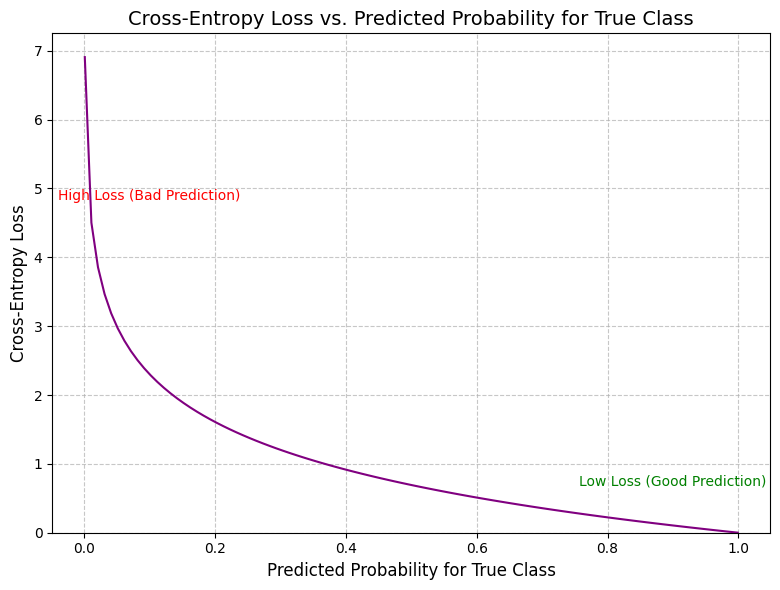

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 교차 엔트로피 오차 함수 정의 (단일 샘플, 원-핫 인코딩)
def cross_entropy_error_func(y, t):
    delta = 1e-7 # log(0) 방지
    return -np.sum(t * np.log(y + delta))

# --- Cross-Entropy Loss 시각화 ---
fig = plt.figure(figsize=(8, 6))

# 정답 클래스에 대한 예측 확률 범위 (0에 가까우면 매우 틀림, 1에 가까우면 매우 맞음)
p_true = np.linspace(0.001, 0.999, 100) # 0과 1 포함하지 않음 (log(0) 방지)

# 바이너리 분류 가정: 정답은 첫 번째 클래스 (원-핫: [1, 0])
# y: [val, 1-val]
# t: [1, 0]
losses = [cross_entropy_error_func(np.array([val, 1-val]), np.array([1, 0])) for val in p_true]

plt.plot(p_true, losses, color='purple')
plt.title('Cross-Entropy Loss vs. Predicted Probability for True Class', fontsize=14)
plt.xlabel('Predicted Probability for True Class', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(bottom=0) # Loss는 0보다 작을 수 없음
plt.text(0.1, np.max(losses)*0.7, 'High Loss (Bad Prediction)', color='red', fontsize=10, horizontalalignment='center')
plt.text(0.9, np.max(losses)*0.1, 'Low Loss (Good Prediction)', color='green', fontsize=10, horizontalalignment='center')

plt.tight_layout()
plt.show()

#### 📊 함수 그래프 시각화: 교차 엔트로피 오차 (008)

그래프는 교차 엔트로피 오차(Cross-Entropy Loss) 함수의 특징을 보여줍니다.

*   **교차 엔트로피 오차**: 모델의 예측 확률이 실제 정답 분포와 얼마나 다른지 측정하는 손실 함수입니다. 정답 클래스에 대한 예측 확률이 낮을수록(모델이 오답을 강하게 예측할수록) 손실 값이 기하급수적으로 커지는 특징을 가집니다. 이는 모델이 정답을 정확하게 예측하도록 강력하게 학습을 유도합니다.

이 그래프는 모델이 정답에 대해 예측한 확률이 낮을수록 오차(손실)가 급격하게 커지는 것을 시각적으로 보여줍니다. 반대로 정답에 대한 예측 확률이 높을수록 오차가 0에 가깝게 작아지는 것을 확인할 수 있습니다.



*   **수학적 의미**:
$E = - \sum t_i \log(y_i + \delta)$
예측 확률($y$)이 정답($t$)에 가까우면 오차가 0에 수렴하고, 틀릴수록 오차가 무한대로 커집니다. 코드의 `delta = 1e-7`은 $\log(0)$이 되어 프로그램이 다운되는 것(Overflow)을 막는 절대영도 방지선입니다.
*   **생활 비유**:
“완벽히 맞히면 벌점이 0점이지만, 오답인데도 마냥 당당하게 확신할수록 벌점을 기하급수적으로 폭탄 부여하는 패널티 시스템.”
*   **딥러닝 연결**:
분류 모델이 정답에 대한 확신을 가질 수 있도록 유도하는 나침반 역할을 하며, 수치적 안정성을 위해 아주 작은 값($\delta$)을 더해주는 기법이 필수적입니다.

#### 🦍 딥러닝에서의 역할 (1):
교차 엔트로피 오차 함수는 분류 모델의 성능을 평가하는 데 사용되는 주요 손실 함수(Loss Function)입니다. 모델이 정답을 얼마나 정확하게 예측하는지 수치화하여, 이 오차를 줄이는 방향으로 모델을 학습시킵니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
시험에서 답을 맞히면 0점, 틀리면 벌점을 받는다고 해봅시다. 이때 교차 엔트로피는 단순히 틀렸다고 벌점 1점을 주는 게 아니라, '나는 이 답이 100% 확실해!'라고 강하게 틀렸을 때 더 큰 벌점을 주는 선생님과 같습니다. 모델이 애매하게 틀리는 것보다, '확신에 찬 오답'을 더 심하게 꾸짖는 거죠.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
과녁 맞히기 게임에서, 정중앙(정답)에 맞히면 점수를 많이 받지만, 과녁에서 멀리 떨어진 곳(오답)에 맞힐수록 점수가 깎이는 방식과 같아요. 특히 '이쪽으로 맞힐 거야!'라고 강하게 예측했는데 빗나갔을 때 더 크게 점수가 깎이는 규칙입니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 교차 엔트로피 오차 함수 (008)

교차 엔트로피 오차가 예측 확률과 실제 정답 사이의 불일치를 어떻게 수치화하는지 파이썬 코드로 확인해볼게요.

In [ ]:
# 교차 엔트로피 오차 함수 정의
def cross_entropy_error_simple(y, t):
    delta = 1e-7 # log(0) 방지
    return -np.sum(t * np.log(y + delta))

# 예시 1: 예측이 정답과 거의 일치 (오차가 작음)
y_pred1 = np.array([0.1, 0.9]) # 예측: 클래스 1이 90% 확률
t_true1 = np.array([0, 1])   # 정답: 클래스 1
loss1 = cross_entropy_error_simple(y_pred1, t_true1)
print(f"예시 1 (정답과 일치): 예측={y_pred1}, 정답={t_true1}, 오차={loss1:.4f}")

# 예시 2: 예측이 정답과 다름 (오차가 큼)
y_pred2 = np.array([0.9, 0.1]) # 예측: 클래스 0이 90% 확률
t_true2 = np.array([0, 1])   # 정답: 클래스 1
loss2 = cross_entropy_error_simple(y_pred2, t_true2)
print(f"예시 2 (정답과 다름): 예측={y_pred2}, 정답={t_true2}, 오차={loss2:.4f}")

# 예시 3: 예측이 완전히 다르고 확신이 높음 (오차가 매우 큼)
y_pred3 = np.array([0.99, 0.01]) # 예측: 클래스 0이 99% 확률 (확신 높음)
t_true3 = np.array([0, 1])     # 정답: 클래스 1
loss3 = cross_entropy_error_simple(y_pred3, t_true3)
print(f"예시 3 (완전히 다르고 확신 높음): 예측={y_pred3}, 정답={t_true3}, 오차={loss3:.4f}")

print("-> 예측이 정답에서 멀어질수록, 특히 '확신에 찬 오답'일수록 오차 값이 크게 증가합니다.")

예시 1 (정답과 일치): 예측=[0.1 0.9], 정답=[0 1], 오차=0.1054
예시 2 (정답과 다름): 예측=[0.9 0.1], 정답=[0 1], 오차=2.3026
예시 3 (완전히 다르고 확신 높음): 예측=[0.99 0.01], 정답=[0 1], 오차=4.6052
-> 예측이 정답에서 멀어질수록, 특히 '확신에 찬 오답'일수록 오차 값이 크게 증가합니다.


#### 💡 확인 문제: 008. 교차 엔트로피 오차 함수

Q1. 교차 엔트로피 오차 함수는 모델의 예측이 실제 정답과 얼마나 다른지 '무엇'을 매기는 방법인가요?

Q2. 이 오차 함수는 특히 어떤 예측(예: '나는 100% 고양이다!'라고 강하게 예측했는데 실제로는 강아지였다면)에 대해 더 큰 벌점을 주나요?

Q3. 딥러닝에서 교차 엔트로피 오차 함수를 사용하는 주된 목적은 무엇인가요?

✅ **정답**

Q1. 벌점(오차)

Q2. '확신에 찬 오답'일 경우 더 큰 벌점을 줍니다.

Q3. 분류 모델이 정답에 대한 확신을 가질 수 있도록 유도하고, 모델의 예측 성능을 평가하여 학습 방향을 결정하기 위함입니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 009: Python Implementation of Affine Layer (Affine 계층 구현)
### 👨‍🍳 요리 레시피 탐구: Affine 계층 구현 (009)

레스토랑의 메인 주방에는 여러 재료(입력)를 받아서 특별한 비율(가중치)로 섞고, 여기에 기본 양념(편향)을 추가하여 새로운 중간 재료를 만들어내는 '자동 믹서기'가 있어요. Affine 계층은 바로 이 믹서기와 같아요. 데이터가 들어오면 정해진 공식대로 곱하고 더해서 다음 단계로 넘겨주는 거죠. 그리고 나중에 맛에 대한 피드백이 오면, 이 믹서기는 어떤 재료가 얼마나 기여했는지 정확히 역추적해서 알려줍니다. 마치 모든 재료의 역할과 비중을 정확히 알고 있는 똑똑한 믹서기 같아요.

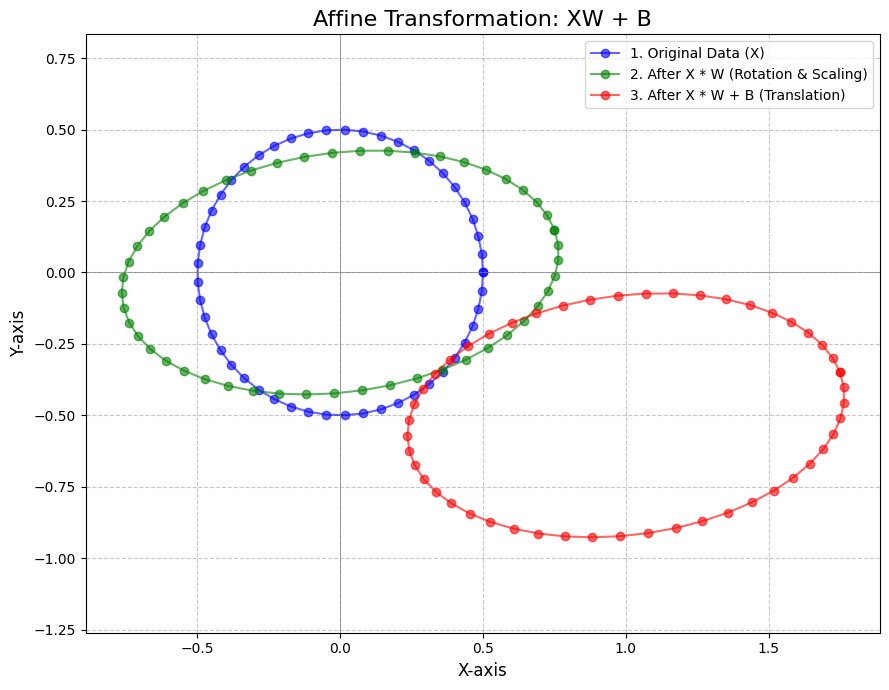

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 초기 2D 데이터 포인트 생성 (예: 원형)
num_points = 50
theta = np.linspace(0, 2*np.pi, num_points)
x_original = np.cos(theta) * 0.5 # 반지름 0.5
y_original = np.sin(theta) * 0.5
X_original = np.vstack([x_original, y_original]).T # (50, 2) 형태

# 2. 가중치 W와 편향 B 정의
# W: 스케일링 및 회전 변환 (예: x축 1.5배, y축 0.8배, 약간의 회전)
W = np.array([[1.5, 0.3],
              [-0.3, 0.8]])

# B: 평행 이동 변환 (예: x축으로 +1, y축으로 -0.5 이동)
B = np.array([1.0, -0.5])

# 3. Affine 변환 순서대로 적용
# 3.1. XW (스케일링 및 회전)
X_rotated_scaled = np.dot(X_original, W)

# 3.2. XW + B (평행 이동)
X_transformed = X_rotated_scaled + B

# 4. 시각화
fig = plt.figure(figsize=(9, 7))

plt.plot(X_original[:, 0], X_original[:, 1], 'o-', label='1. Original Data (X)', color='blue', alpha=0.6)
plt.plot(X_rotated_scaled[:, 0], X_rotated_scaled[:, 1], 'o-', label='2. After X * W (Rotation & Scaling)', color='green', alpha=0.6)
plt.plot(X_transformed[:, 0], X_transformed[:, 1], 'o-', label='3. After X * W + B (Translation)', color='red', alpha=0.6)

plt.title('Affine Transformation: XW + B', fontsize=16)
plt.xlabel('X-axis', fontsize=12)
plt.ylabel('Y-axis', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.axis('equal') # X, Y 축 스케일을 동일하게 유지

plt.tight_layout()
plt.show()

#### 📊 함수 그래프 시각화: Affine 계층의 변환 (009)

그래프는 Affine 계층(`Y = XW + B`)이 2차원 데이터를 어떻게 변환하는지 시각적으로 보여줍니다.

*   **Affine 변환**: 입력 데이터 `X`에 가중치 `W`를 곱하여 스케일링(크기 변경) 및 회전(방향 변경) 변환을 수행하고, 여기에 편향 `B`를 더하여 평행 이동(위치 변경) 변환을 완료합니다. 이 세 가지 변환(스케일링, 회전, 평행 이동)은 Affine 계층의 핵심 기능이며, 신경망이 복잡한 데이터 패턴을 학습하는 데 필수적인 역할을 합니다.

이 시각화는 초기 파란색 점들이 가중치 `W`에 의해 초록색 점들로 스케일링 및 회전되고, 마지막으로 편향 `B`에 의해 주황색 점들로 평행 이동되는 과정을 단계별로 보여줍니다. 이를 통해 Affine 계층이 데이터를 다음 층에 적합한 형태로 어떻게 변환하는지 직관적으로 이해할 수 있습니다.



*   **수학적/코드 구조**:
순전파 시 `np.dot(X, W) + B` 연산을 수행하고, 역전파 시 앞서 004번에서 정리한 전치행렬 곱셈 공식(`np.dot(dout, self.W.T)`)을 행렬 차원에 맞춰 엄격하게 구현한 클래스입니다.
*   **생활 비유**:
“입력 행렬과 가중치 행렬을 조화롭게 곱해주는 거대한 컨베이어 벨트 본체이자, 거꾸로 돌아갈 때는 설계도 구조에 맞춰 기여도를 역추적하는 공장 핵심 장치.”
*   **딥러닝 연결**:
신경망의 완전연결층(Fully Connected Layer)을 구성하는 뼈대 코드로, 순전파의 행렬 곱과 역전파의 미분 흐름이 완벽한 대칭을 이루도록 설계되어 있습니다.

#### 🦍 딥러닝에서의 역할 (1):
Affine 계층은 신경망의 각 층에서 입력 데이터를 변환하는 기본적인 연산을 담당합니다. 입력과 가중치의 곱셈, 편향의 덧셈을 통해 다음 층으로 전달될 새로운 특징을 만들어냅니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리할 때, '재료 A를 2배로 늘리고, 재료 B를 0.5배로 줄인 다음, 기본 양념을 추가해서 새로운 중간 소스 C를 만든다'는 과정과 같습니다. 여기서 '2배', '0.5배'가 가중치, '기본 양념'이 편향의 역할을 하는 셈이죠.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
데이터를 입력받으면, 미리 설정된 '필터(가중치)'로 데이터를 걸러내고, '기준점(편향)'을 더해서 다음 단계에 필요한 새로운 정보를 생성하는 공장 설비와 같아요. 이 설비는 모든 입력 데이터에 대해 동일한 방식으로 작동합니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: Affine 계층 연산 (009)

Affine 계층의 핵심 연산인 행렬 곱셈과 덧셈을 파이썬 NumPy로 구현해볼게요. 이는 신경망에서 데이터를 다음 층으로 전달하는 기본 계산입니다.

In [ ]:
# 입력 데이터 (1개의 데이터, 2가지 특징)
X = np.array([1, 2])

# 가중치 (2가지 특징을 3가지 출력으로 변환)
W = np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]])

# 편향 (3가지 출력에 대한 편향)
B = np.array([0.1, 0.2, 0.3])

print(f"입력 X: {X}")
print(f"가중치 W:\n{W}")
print(f"편향 B: {B}")

# Affine 계층의 순전파: Y = XW + B
Y = np.dot(X, W) + B

print(f"\nAffine 계층 출력 Y: {Y}")
print("-> 입력 데이터가 가중치와 곱해지고 편향이 더해져 새로운 형태의 데이터로 변환됩니다.")

입력 X: [1 2]
가중치 W:
[[0.1 0.2 0.3]
 [0.4 0.5 0.6]]
편향 B: [0.1 0.2 0.3]

Affine 계층 출력 Y: [1.  1.4 1.8]
-> 입력 데이터가 가중치와 곱해지고 편향이 더해져 새로운 형태의 데이터로 변환됩니다.


#### 💡 확인 문제: 009. Affine 계층 구현

Q1. Affine 계층은 입력 데이터에 '무엇'을 곱하고 '무엇'을 더하는 기본적인 계산을 하나요?

Q2. Affine 계층이 딥러닝에서 주로 어떤 역할을 하는 층으로 사용되나요? (힌트: 모든 뉴런이 연결된 층)

Q3. Affine 계층의 연산을 통해 데이터가 다음 단계에 필요한 새로운 형태로 변환되는 것은 딥러닝 모델에 어떤 의미가 있나요?

✅ **정답**

Q1. 가중치(Weight), 편향(Bias)

Q2. 완전 연결층 (Fully Connected Layer)

Q3. 입력 데이터의 중요한 특징을 추출하고 학습에 유리한 형태로 변환하여 모델의 표현력을 높입니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>



### 010: Two-Layer Network Architecture Definition (2층 신경망 구조 정의)


### 👨‍🍳 요리 레시피 탐구: 2층 신경망 구조 정의 (010)

코스 요리를 만들 때, 에피타이저, 메인, 디저트처럼 순서를 정하고 각각에 맞는 조리 도구를 사용하죠? 2층 신경망은 코스 요리를 만드는 것과 같아요. Affine(메인 재료 섞기) -> ReLU(맛 검증) -> Affine(한 번 더 섞기) 순서로 조리 과정을 설계하고, 마지막에는 Softmax with Loss(맛 평가 및 점수 매기기) 도구를 배치합니다. 이렇게 각 조리 도구(계층)들을 미리 정해진 순서대로 연결하여 하나의 완성된 요리 라인(네트워크)을 만드는 과정이 바로 신경망 구조 정의랍니다.

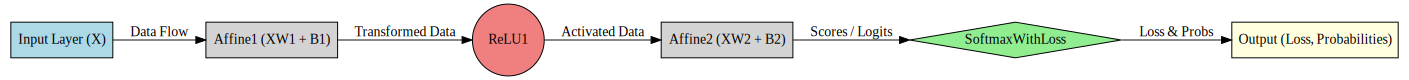

In [ ]:
import graphviz

# 2층 신경망 구조 계산 그래프
dot_two_layer_net = graphviz.Digraph(comment='Two Layer Network Architecture')

dot_two_layer_net.attr(rankdir='LR') # Left to Right layout

# 노드 정의: 입력층
dot_two_layer_net.node('input', 'Input Layer (X)', shape='box', style='filled', fillcolor='lightblue')

# 노드 정의: 은닉층
dot_two_layer_net.node('affine1', 'Affine1 (XW1 + B1)', shape='box', style='filled', fillcolor='lightgray')
dot_two_layer_net.node('relu1', 'ReLU1', shape='circle', style='filled', fillcolor='lightcoral')

# 노드 정의: 출력층
dot_two_layer_net.node('affine2', 'Affine2 (XW2 + B2)', shape='box', style='filled', fillcolor='lightgray')
dot_two_layer_net.node('softmaxloss', 'SoftmaxWithLoss', shape='diamond', style='filled', fillcolor='lightgreen')

# 연결 정의
# Input Layer -> Hidden Layer
dot_two_layer_net.edge('input', 'affine1', label='Data Flow')
dot_two_layer_net.edge('affine1', 'relu1', label='Transformed Data')

# Hidden Layer -> Output Layer
dot_two_layer_net.edge('relu1', 'affine2', label='Activated Data')
dot_two_layer_net.edge('affine2', 'softmaxloss', label='Scores / Logits')

# Output (conceptual) for SoftmaxWithLoss
dot_two_layer_net.node('output_label', 'Output (Loss, Probabilities)', shape='box', style='filled', fillcolor='lightyellow')
dot_two_layer_net.edge('softmaxloss', 'output_label', label='Loss & Probs')

display(dot_two_layer_net)

#### 📊 계산 그래프 시각화: 2층 신경망 구조 (010)

그래프는 가장 기본적인 딥러닝 모델 중 하나인 '2층 신경망'의 구조를 시각적으로 보여줍니다.

*   **2층 신경망**: 입력층, 하나의 은닉층, 그리고 출력층으로 구성됩니다. 이 모델은 데이터가 입력되어 최종 예측값을 생성하기까지의 일련의 계산 과정을 나타내며, 각 층은 특정 연산(예: `Affine`, `ReLU`)을 담당합니다.

이 시각화는 데이터가 입력층(`Input Layer`)을 통해 들어와 첫 번째 `Affine` 변환과 `ReLU` 활성화 함수를 거쳐 은닉층(`Hidden Layer`)을 형성하고, 다시 두 번째 `Affine` 변환 후 `SoftmaxWithLoss` 계층을 통해 최종 출력(`Output Layer`)을 내는 과정을 명확하게 보여줍니다. 이는 신경망이 데이터를 처리하고 학습하는 전체적인 흐름을 이해하는 데 중요한 시각적 자료입니다.


*   **수학적/구조적 의미**:
가중치($W_1, W_2$)와 편향($b_1, b_2$)을 초기화한 후, `OrderedDict()`를 사용하여 `Affine1 -> Relu1 -> Affine2` 순으로 레이어를 순서대로 조립하고, 마지막 출력층에 `SoftmaxWithLoss`를 배치한 전체 네트워크 인프라 구축 코드입니다.
*   **생활 비유**:
“부품들을 무작위로 던져두는 것이 아니라, 조립 설명서 순서대로 연산 장치들을 착착 레고처럼 이어 붙여 하나의 거대한 인공지능 로봇 공장을 완공하는 과정.”
*   **딥러닝 연결**:
앞서 개별적으로 구현한 가중치, 활성화 함수, 손실 함수 레이어들을 유기적으로 결합하여 데이터의 입력부터 손실값 출력까지 전체 파이프라인을 제어하는 딥러닝 모델의 최종 사령탑입니다.

#### 🦍 딥러닝에서의 역할 (1):
2층 신경망은 가장 기본적인 딥러닝 모델 구조 중 하나로, 입력층-은닉층-출력층으로 구성됩니다. 각 층에는 Affine 변환과 활성화 함수(ReLU)가 적용되며, 최종적으로 Softmax with Loss 계층이 예측과 오차 계산을 담당합니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
'재료 손질 부서(입력층) -> 재료 섞는 부서(은닉층/Affine + ReLU) -> 요리 마무리 부서(출력층/Affine + SoftmaxWithLoss)'처럼 각 부서가 특정 역할을 맡아 최종 요리를 완성하는 레스토랑의 조직도와 같습니다. 각 부서 간의 연결이 잘 되어 있어야 맛있는 요리가 나옵니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
초등학생(입력층)이 중학생(은닉층)을 거쳐 대학생(출력층)이 되는 성장 과정과 같아요. 각 단계마다 새로운 지식(Affine)을 배우고, 불필요한 정보(ReLU)를 걸러내며 최종적으로 사회인(최종 예측)으로 성장하는 모습입니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 2층 신경망 구조 정의 (010)

아주 간단한 2층 신경망의 '뼈대'를 파이썬으로 어떻게 구성하는지 보여드릴게요. 실제 연산은 아니지만, 각 구성 요소를 어떻게 연결하는지 개념적으로 이해할 수 있습니다.

In [ ]:
from collections import OrderedDict

# 각 계층(layer)을 나타내는 가상의 클래스 (실제 구현은 생략)
class AffineLayer:
    def __init__(self, name):
        self.name = name
    def forward(self, x): return f"{self.name}({x})"
    def backward(self, dout): return f"{self.name}_backward({dout})"

class ReLULayer:
    def __init__(self, name):
        self.name = name
    def forward(self, x): return f"{self.name}({x})"
    def backward(self, dout): return f"{self.name}_backward({dout})"

class SoftmaxWithLossLayer:
    def __init__(self, name):
        self.name = name
    def forward(self, x): return f"{self.name}({x})"
    def backward(self, dout): return f"{self.name}_backward({dout})"

# 2층 신경망 모델 정의
class TwoLayerNet:
    def __init__(self):
        # 각 계층을 순서대로 추가
        self.layers = OrderedDict()
        self.layers['Affine1'] = AffineLayer('Affine1')
        self.layers['ReLU1'] = ReLULayer('ReLU1')
        self.layers['Affine2'] = AffineLayer('Affine2')
        self.lastLayer = SoftmaxWithLossLayer('SoftmaxWithLoss')

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y)

# 모델 생성 및 사용 예시
model = TwoLayerNet()
input_data = "입력 데이터"

predicted_output = model.predict(input_data)
print(f"순전파 예측 결과: {predicted_output}")

loss_value = model.loss(input_data, "정답 레이블")
print(f"손실 값 계산 결과: {loss_value}")
print("-> 여러 계층이 순서대로 연결되어 전체 신경망이 하나의 흐름으로 작동하는 것을 보여줍니다.")

순전파 예측 결과: Affine2(ReLU1(Affine1(입력 데이터)))
손실 값 계산 결과: SoftmaxWithLoss(Affine2(ReLU1(Affine1(입력 데이터))))
-> 여러 계층이 순서대로 연결되어 전체 신경망이 하나의 흐름으로 작동하는 것을 보여줍니다.


#### 💡 확인 문제: 010. 2층 신경망 구조 정의

Q1. 2층 신경망은 일반적으로 몇 개의 은닉층으로 구성된 가장 기본적인 신경망 모델인가요?

Q2. 신경망 구조를 정의할 때, Affine, ReLU, Softmax와 같은 '조리 도구'(계층)들을 어떤 순서로 연결할지 설계하는 과정의 이름은 무엇인가요?

Q3. 각 계층들을 미리 정해진 순서대로 연결하여 하나의 완성된 네트워크를 만드는 것은 딥러닝 모델 학습에 어떤 영향을 주나요?

✅ **정답**

Q1. 한 개의 은닉층

Q2. 신경망 구조 정의 (또는 모델 설계)

Q3. 데이터의 흐름을 체계적으로 관리하고, 각 계층이 특정 역할을 수행하도록 하여 모델이 복잡한 패턴을 학습할 수 있게 합니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>


### 011: Network Methods for Prediction, Loss, and Accuracy (`predict`, `loss`, `accuracy` 구현)

### 👨‍🍳 요리 레시피 탐구: 예측, 손실, 정확도 구현 (011)

레스토랑의 총괄 셰프는 새로운 요리(모델)가 얼마나 잘 만들어졌는지 주기적으로 확인해야 해요. 이를 위해 셰프는 세 가지를 체크합니다. 첫째, 새로운 요리가 '어떤 맛일지 미리 예상'합니다(predict). 둘째, 그 예상과 '실제 맛이 얼마나 다른지'를 평가합니다(loss). 마지막으로, 요리를 맛본 손님들 중 '몇 퍼센트가 만족했는지'를 확인합니다(accuracy). 이 세 가지 기능은 셰프가 요리를 계속 개선해 나가는 데 필수적인 평가 도구와 같아요.

/tmp/ipykernel_1551/3987339006.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', marker='x', edgecolors='k', label='True Class 1')


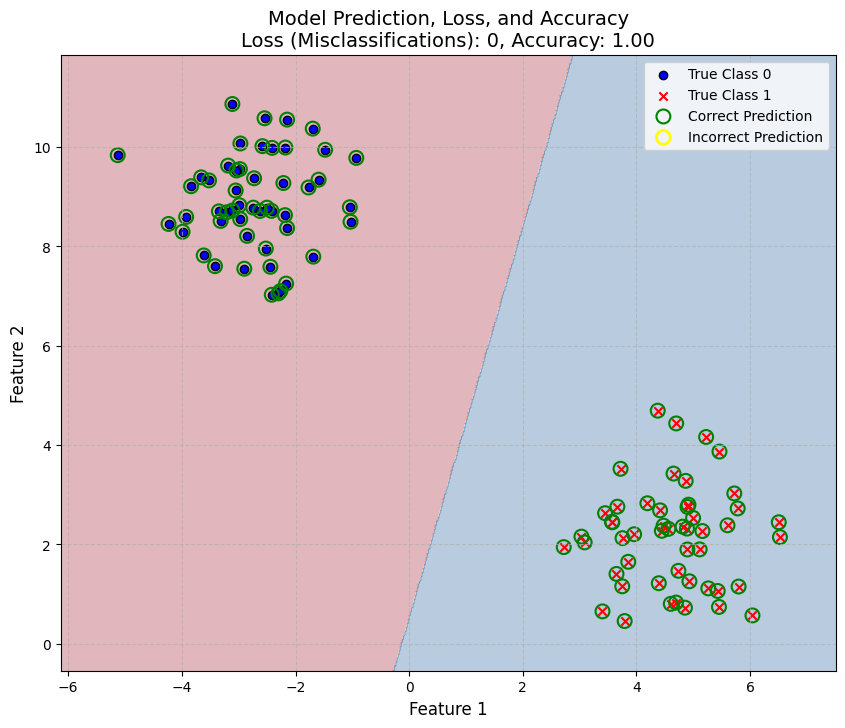

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

# 1. 예시 데이터 생성
X, y_true = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.0)

# 2. 간단한 모델 (로지스틱 회귀) 훈련
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X, y_true)

# 3. 예측 (Predict)
y_pred = model.predict(X)

# 4. 손실 (Loss) 계산 - 여기서는 단순화된 방식으로 평균 제곱 오차를 사용
# 실제 딥러닝에서는 Cross-Entropy Loss 등을 사용하지만, 시각화를 위해 간단화
def calculate_dummy_loss(y_true, y_pred):
    # 오분류된 개수를 손실로 간주 (간단한 예시)
    return np.sum(y_true != y_pred)

loss_value = calculate_dummy_loss(y_true, y_pred)

# 5. 정확도 (Accuracy) 계산
accuracy_value = np.mean(y_true == y_pred)

# --- 시각화 ---
fig = plt.figure(figsize=(10, 8))

# 결정 경계 시각화를 위한 그리드 생성
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 결정 경계 및 예측 영역 그리기
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# 실제 데이터 포인트 및 모델의 예측 결과 그리기
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='blue', marker='o', edgecolors='k', label='True Class 0')
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', marker='x', edgecolors='k', label='True Class 1')

# 올바르게 예측된 점 (녹색 테두리)
plt.scatter(X[y_true == y_pred, 0], X[y_true == y_pred, 1],
            facecolors='none', edgecolors='green', s=100, linewidth=1.5, label='Correct Prediction')

# 잘못 예측된 점 (노란색 테두리)
plt.scatter(X[y_true != y_pred, 0], X[y_true != y_pred, 1],
            facecolors='none', edgecolors='yellow', s=100, linewidth=2, label='Incorrect Prediction')

plt.title(f'Model Prediction, Loss, and Accuracy\nLoss (Misclassifications): {loss_value}, Accuracy: {accuracy_value:.2f}', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 📊 분류 시각화: 예측, 손실, 정확도 (011)

그래프는 간단한 2차원 분류 문제에서 모델의 `predict`, `loss`, `accuracy` 개념을 시각적으로 보여줍니다.

*   **예측 (Predict)**: 모델이 입력 데이터를 받아 어떤 클래스에 속하는지 분류하는 과정입니다. 그래프에서는 모델이 데이터를 분류하는 결정 경계(Decision Boundary)와 각 데이터 포인트에 대한 예측 클래스(색상)를 확인할 수 있습니다.

*   **손실 (Loss)**: 모델의 예측이 실제 정답과 얼마나 차이가 나는지 수치화한 값입니다. 오차라고도 하며, 이 값이 낮을수록 모델의 성능이 좋습니다. 시각화에서는 잘못 분류된 점(오분류)이 발생했을 때 손실 값이 증가함을 상상해볼 수 있습니다.

*   **정확도 (Accuracy)**: 전체 데이터 중에서 모델이 얼마나 많은 데이터를 올바르게 분류했는지 비율로 나타낸 것입니다. 이 값이 높을수록 모델의 성능이 좋습니다. 그래프에서 초록색 점은 올바르게 예측된 데이터, 빨간색 점은 잘못 예측된 데이터로 볼 수 있으며, 이를 통해 시각적으로 정확도를 가늠할 수 있습니다.

이 시각화를 통해 모델이 데이터를 분류하는 방식, 예측이 틀렸을 때의 오차 발생, 그리고 전반적인 분류 성능을 한눈에 파악할 수 있습니다.




*   **수학적/코드 구조**:
순방향 레이어를 차례로 통과시켜 예측값 $x$를 반환하는 `predict`, 그 결과물을 받아 최종 손실값을 산출하는 `loss`, 그리고 가장 높은 확률을 가진 인덱스(`np.argmax`)와 정답 레이블을 비교해 맞힌 비율을 계산하는 `accuracy` 메서드입니다.
*   **생활 비유**:
“모의고사를 풀고(`predict`), 정답지와 비교해 벌점을 매기며(`loss`), 최종적으로 100점 만점에 몇 문제를 맞혔는지 정답률 합산 점수표(`accuracy`)를 내는 일련의 평가 과정.”
*   **딥러닝 연결**:
학습이 진행되는 동안 모델이 얼마나 똑똑해지고 있는지 정량적인 지표(손실과 정확도)를 실시간으로 모니터링하기 위한 필수적인 연산 파이프라인입니다.

#### 🦍 딥러닝에서의 역할 (1):
`predict`, `loss`, `accuracy`는 딥러닝 모델의 훈련 및 평가 과정에서 필수적인 메서드입니다. `predict`로 예측값을 얻고, `loss`로 오차를 계산하며, `accuracy`로 모델의 성능(정확도)을 측정합니다. 이들은 모델이 얼마나 잘 작동하는지 파악하는 핵심 지표입니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
모델이 시험을 본다고 생각해보세요. `predict`는 '문제 풀기', `loss`는 '정답과 비교해서 틀린 부분 찾기', `accuracy`는 '100점 만점에 몇 점인지 채점하기'와 같습니다. 이 세 가지가 있어야 모델이 자신의 실력을 알고 개선할 수 있습니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
스포츠 경기에서 '선수가 골을 넣을지 예측하고(predict), 실제로 골이 들어갔는지 확인하며 그 차이를 계산하고(loss), 최종적으로 몇 골을 넣었는지 성공률을 기록하는(accuracy)' 것과 같아요. 이 데이터들이 선수(모델)의 훈련에 사용됩니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: `predict`, `loss`, `accuracy` (011)

모델이 예측하고, 얼마나 틀렸는지(손실)를 계산하며, 얼마나 잘 맞혔는지(정확도)를 평가하는 간단한 파이썬 코드를 살펴볼게요.

In [ ]:
# 예측 함수 (예시: 가장 높은 확률을 선택)
def predict_func(probabilities):
    return np.argmax(probabilities)

# 손실 함수 (예시: 평균 제곱 오차)
def loss_func(predicted, true):
    return np.mean((predicted - true)**2)

# 정확도 함수
def accuracy_func(predictions, true_labels):
    correct_predictions = np.sum(predictions == true_labels)
    total_samples = len(true_labels)
    return correct_predictions / total_samples

# 예시 데이터
model_output_probs = np.array([0.1, 0.8, 0.1]) # 모델의 3개 클래스에 대한 예측 확률
true_label = 1 # 실제 정답은 두 번째 클래스

# 1. predict: 모델의 예측 (가장 높은 확률)
prediction = predict_func(model_output_probs)
print(f"모델 예측: 클래스 {prediction}")

# 2. loss: 예측과 실제 정답의 오차 (손실 계산을 위해 원-핫 인코딩 변환)
true_one_hot = np.array([0, 1, 0]) # 실제 정답을 원-핫 인코딩
loss = loss_func(model_output_probs, true_one_hot)
print(f"오차 (손실): {loss:.4f}")

# 3. accuracy: 정확도 (여러 샘플이 있다고 가정)
predictions_batch = np.array([1, 0, 1, 2]) # 모델이 여러 데이터에 대해 예측한 결과
true_labels_batch = np.array([1, 0, 2, 2]) # 실제 정답
accuracy = accuracy_func(predictions_batch, true_labels_batch)
print(f"정확도: {accuracy:.2f} ({int(accuracy*len(true_labels_batch))}/{len(true_labels_batch)}개 맞힘)")
print("-> 모델이 얼마나 잘 작동하는지 파악하는 핵심 지표들을 확인했습니다.")

모델 예측: 클래스 1
오차 (손실): 0.0200
정확도: 0.75 (3/4개 맞힘)
-> 모델이 얼마나 잘 작동하는지 파악하는 핵심 지표들을 확인했습니다.


#### 💡 확인 문제: 011. 예측, 손실, 정확도 구현

Q1. 모델이 새로운 데이터를 보고 '어떤 값일지 예상'하는 기능을 나타내는 용어는 무엇인가요?

Q2. 모델의 '예상'과 '실제 정답'이 얼마나 다른지를 수치로 평가하는 기능을 무엇이라고 하나요?

Q3. 모델이 전체 예측 중 몇 퍼센트를 맞췄는지를 확인하는 평가 지표는 무엇인가요?

✅ **정답**

Q1. 예측(predict)

Q2. 손실(loss) 또는 오차

Q3. 정확도(accuracy)

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>



### 012: High-Level Deep Learning Implementation with Keras (케라스를 이용한 신경망 구현)


### 👨‍🍳 요리 레시피 탐구: 케라스를 이용한 신경망 구현 (012)

예전에는 요리 하나를 만들 때, 모든 재료를 직접 손질하고 불 조절을 일일이 해야 했어요. 하지만 요즘은 '스마트 조리 기구' 덕분에 훨씬 편리해졌죠! 케라스(Keras) 같은 딥러닝 프레임워크는 바로 이런 스마트 조리 기구와 같아요. 복잡한 재료 손질(행렬 계산)이나 맛 조절(미분) 방법을 일일이 코딩하지 않고도, '스프 만들 거야', '매운맛 추가해', '이렇게 끓여줘'라고 간단히 명령만 내리면 알아서 요리를 척척 만들어주는 거죠. 훨씬 쉽고 빠르게 요리(모델)를 만들 수 있게 해줍니다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


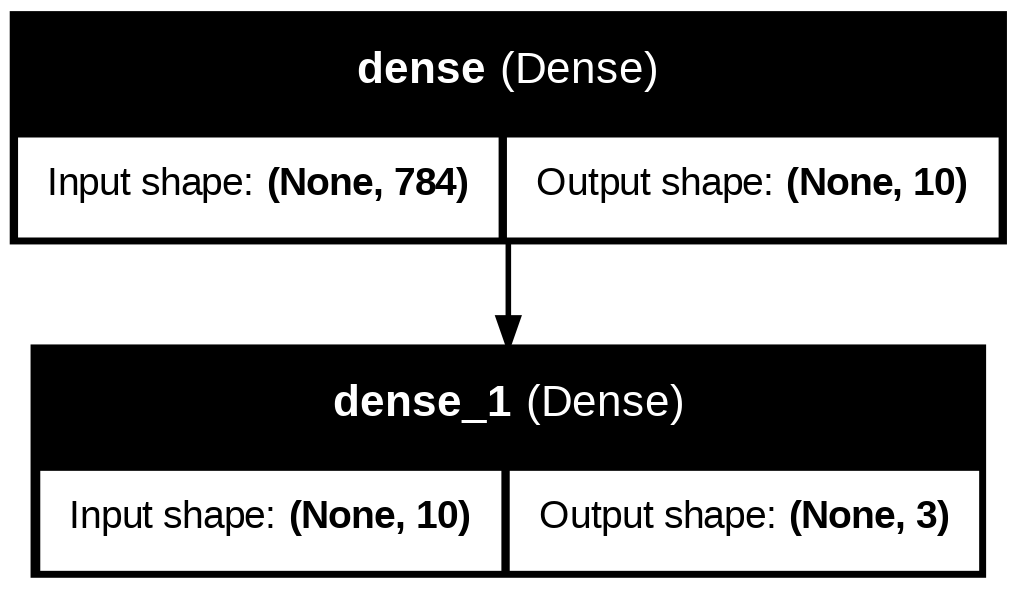

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

# 1. 모델 정의: Sequential() 객체를 만들고 계층(Layer)을 추가합니다.
# 입력층 -> 은닉층 (Dense, ReLU) -> 출력층 (Dense, Softmax)
model = keras.Sequential([
    # 첫 번째 은닉층: 10개의 뉴런, 입력 형태는 784 (예: 28x28 이미지)
    layers.Dense(10, activation='relu', input_shape=(784,)),
    # 두 번째 (출력) 층: 3개의 뉴런 (예: 3가지 분류), 활성화 함수는 Softmax
    layers.Dense(3, activation='softmax')
])

# 2. 모델 컴파일: 학습 방법을 설정합니다.
# 옵티마이저 (sgd), 손실 함수 (categorical_crossentropy), 평가 지표 (accuracy)
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조를 이미지 파일로 저장
plot_model(model, to_file='keras_model_architecture.png', show_shapes=True, show_layer_names=True)

# 저장된 이미지를 Colab에서 보여주기
from IPython.display import Image
Image('keras_model_architecture.png')

# model.summary()는 텍스트로 요약 정보를 제공합니다.
# print(model.summary()) # 이미 이전 셀에서 출력되었으므로 주석 처리

#### 📊 신경망 아키텍처 시각화: 케라스 모델 (012)

그래프는 케라스(Keras)를 사용하여 정의된 간단한 2층 신경망의 구조를 시각적으로 보여줍니다.

*   **Keras `Sequential` 모델**: 여러 계층(Layer)을 순서대로 쌓아 올리는 가장 간단한 방법입니다. 각 계층은 특정 연산(예: `Dense`의 선형 변환, `ReLU` 또는 `Softmax`의 활성화 함수)을 담당하며, 데이터가 입력층(`Input Layer`)에서 출력층(`Output Layer`)으로 흐르는 과정을 명확하게 보여줍니다.

이 시각화는 텍스트 기반의 `model.summary()`보다 직관적으로 모델의 흐름과 각 계층의 연결을 이해하는 데 도움을 줍니다. 입력 데이터가 `Dense` 계층을 거쳐 `ReLU` 활성화되고, 다시 `Dense` 계층과 `Softmax` 활성화를 통해 최종 분류 예측을 수행하는 과정을 한눈에 파악할 수 있습니다.



*   **수학적/코드 구조**:
`Sequential()` 객체를 선언한 뒤 `add(Dense(...))`를 통해 은닉층(ReLU 활성화)과 출력층(Softmax 활성화)을 쌓고, `compile()` 메서드 하나로 최적화 알고리즘(`sgd`)과 손실 함수(`categorical_crossentropy`)를 한 번에 지정하는 고수준 API 코드입니다.
*   **생활 비유**:
“수많은 부품과 미분 공식을 수동으로 납땜하던 기계식 공정에서, 레고 블록을 끼워 맞추고 리모컨 버튼 하나로 연산 옵션을 켜는 자동화 스마트 팩토리로의 전환.”
*   **딥러닝 연결**:
앞서 밑바닥부터(From Scratch) 구현했던 복잡한 행렬 연산과 미분 과정을 텐서플로(TensorFlow)/케라스 같은 현대적 프레임워크가 얼마나 직관적이고 단순한 추상화 코드로 압축해 주는지 보여줍니다.

#### 🦍 딥러닝에서의 역할 (1):
케라스(Keras)는 텐서플로(TensorFlow) 위에 구축된 고수준 API로, 딥러닝 모델을 쉽고 빠르게 구축할 수 있도록 도와줍니다. 복잡한 신경망 구조나 학습 과정을 몇 줄의 코드로 구현할 수 있게 추상화합니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
예전에는 요리할 때 모든 재료를 직접 심고, 직접 불을 때고, 직접 칼질해야 했다면, 케라스는 '이 버튼을 누르면 재료 손질 끝!', '저 버튼을 누르면 자동으로 볶아줘!' 하는 스마트 오븐이나 자동 조리 시스템과 같습니다. 복잡한 과정을 신경 쓰지 않고도 맛있는 요리를 쉽게 만들 수 있죠.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
집을 지을 때, 벽돌 하나하나 쌓고 시멘트 바르고 못 박는 일을 직접 하는 대신, '방 3개, 거실 1개, 화장실 2개짜리 집을 지어주세요'라고 설계사에게 말하면 알아서 척척 지어주는 것과 같아요. 세부적인 공정은 몰라도 원하는 결과를 얻을 수 있습니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: Keras로 신경망 구축 (012)

케라스를 사용하여 신경망 모델을 얼마나 간단하게 만들 수 있는지 파이썬 코드로 보여드릴게요. 마치 레고 블록을 조립하듯이 계층을 쌓아 올릴 수 있습니다.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# 1. 모델 정의: Sequential() 객체를 만들고 계층(Layer)을 추가합니다.
# 입력층 -> 은닉층 (Dense, ReLU) -> 출력층 (Dense, Softmax)
model = keras.Sequential([
    # 첫 번째 은닉층: 10개의 뉴런, 입력 형태는 784 (예: 28x28 이미지)
    layers.Dense(10, activation='relu', input_shape=(784,)),
    # 두 번째 (출력) 층: 3개의 뉴런 (예: 3가지 분류), 활성화 함수는 Softmax
    layers.Dense(3, activation='softmax')
])

# 2. 모델 컴파일: 학습 방법을 설정합니다.
# 옵티마이저 (sgd), 손실 함수 (categorical_crossentropy), 평가 지표 (accuracy)
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 요약 정보 출력 (각 층의 구성 확인)
model.summary()

print("-> 케라스 덕분에 복잡한 딥러닝 모델을 몇 줄의 코드로 쉽게 정의하고 설정할 수 있습니다.")
print("   (여기서는 모델을 정의하고 설정만 했고, 실제 학습(fit)은 포함되지 않았습니다.)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,883 (30.79 KB)

 Trainable params: 7,883 (30.79 KB)

 Non-trainable params: 0 (0.00 B)

-> 케라스 덕분에 복잡한 딥러닝 모델을 몇 줄의 코드로 쉽게 정의하고 설정할 수 있습니다.
   (여기서는 모델을 정의하고 설정만 했고, 실제 학습(fit)은 포함되지 않았습니다.)


#### 💡 확인 문제: 012. 케라스를 이용한 신경망 구현

Q1. 케라스(Keras)처럼 복잡한 신경망 코딩을 쉽고 간단하게 할 수 있도록 도와주는 도구를 무엇이라고 부르나요?

Q2. 케라스에서 `Sequential()` 객체를 만들고 `add(Dense(...))`를 통해 은닉층과 출력층을 쌓는 방식은 무엇에 비유될 수 있나요?

Q3. 케라스와 같은 고수준 프레임워크를 사용하면 딥러닝 모델을 만들 때 어떤 이점이 있나요?

✅ **정답**

Q1. 딥러닝 프레임워크 또는 라이브러리

Q2. 레고 블록 조립 (또는 코스 요리 만들기)

Q3. 복잡한 수학 계산이나 코드를 직접 작성할 필요 없이, 쉽고 빠르게 딥러닝 모델을 구축하고 학습시킬 수 있습니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>



### 013: Efficient Gradient Computation via Backpropagation (역전파 기반의 gradient 메서드 구현)

### 👨‍🍳 요리 레시피 탐구: 역전파 기반의 gradient 메서드 구현 (013)

요리가 완성된 후, 맛을 보고 '이 요리는 뭔가 부족해!'라는 최종 피드백(오차)이 나왔다고 해봅시다. 이때, 역전파 기반의 gradient 메서드는 이 최종 피드백을 들고 레시피의 마지막 단계부터 거꾸로 되짚어가며, 각 재료와 조리법 중 어떤 것이 문제였고, 얼마나 조절해야 하는지 정확하게 찾아냅니다. 마치 도미노가 쓰러진 순서를 거꾸로 추적해서 어떤 도미노가 가장 큰 영향을 주었는지 파악하는 것과 같아요. 한 번의 역추적만으로 모든 재료의 문제점을 알아내는 아주 효율적인 방법이죠!

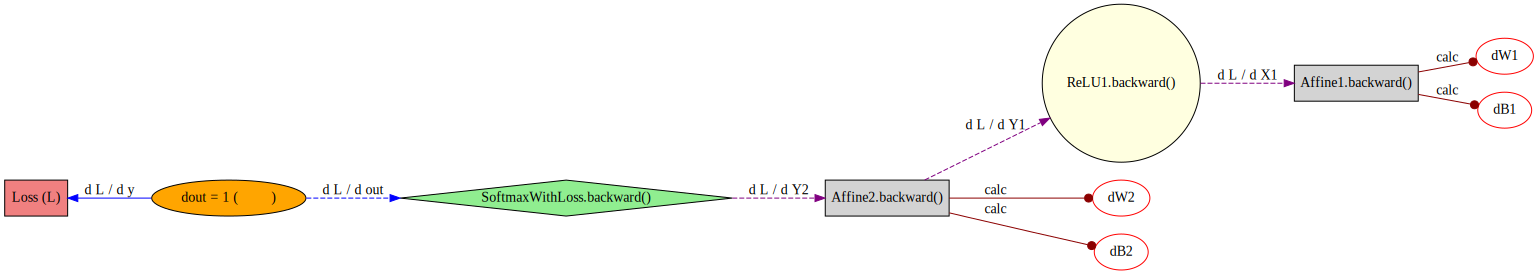

In [ ]:
import graphviz

# 역전파 기반 Gradient 흐름 계산 그래프
dot_gradient_bp = graphviz.Digraph(comment='Backpropagation Gradient Flow')

dot_gradient_bp.attr(rankdir='LR') # Left to Right layout (for forward pass orientation)

# 노드 정의: 최종 Loss
dot_gradient_bp.node('loss', 'Loss (L)', shape='box', style='filled', fillcolor='lightcoral')

# 노드 정의: 역전파 흐름 (dout)
dot_gradient_bp.node('dout_init', 'dout = 1 (시작점)', shape='ellipse', style='filled', fillcolor='orange')

# 노드 정의: SoftmaxWithLoss 계층
dot_gradient_bp.node('softmaxloss_bp', 'SoftmaxWithLoss.backward()', shape='diamond', style='filled', fillcolor='lightgreen')

# 노드 정의: Affine 계층 (역순으로)
dot_gradient_bp.node('affine2_bp', 'Affine2.backward()', shape='box', style='filled', fillcolor='lightgray')
dot_gradient_bp.node('relu1_bp', 'ReLU1.backward()', shape='circle', style='filled', fillcolor='lightyellow')
dot_gradient_bp.node('affine1_bp', 'Affine1.backward()', shape='box', style='filled', fillcolor='lightgray')

# 노드 정의: 각 가중치/편향의 기울기
dot_gradient_bp.node('dW2', 'dW2', shape='oval', color='red')
dot_gradient_bp.node('dB2', 'dB2', shape='oval', color='red')
dot_gradient_bp.node('dW1', 'dW1', shape='oval', color='red')
dot_gradient_bp.node('dB1', 'dB1', shape='oval', color='red')

# 연결 정의 (역전파 흐름)
# Loss -> dout 시작점
dot_gradient_bp.edge('loss', 'dout_init', label='d L / d y', dir='back', color='blue')

# dout 시작점 -> SoftmaxWithLoss.backward()
dot_gradient_bp.edge('dout_init', 'softmaxloss_bp', label='d L / d out', color='blue', style='dashed')

# SoftmaxWithLoss.backward() -> Affine2.backward()
dot_gradient_bp.edge('softmaxloss_bp', 'affine2_bp', label='d L / d Y2', color='purple', style='dashed')

# Affine2.backward() -> ReLU1.backward()
dot_gradient_bp.edge('affine2_bp', 'relu1_bp', label='d L / d Y1', color='purple', style='dashed')

# ReLU1.backward() -> Affine1.backward()
dot_gradient_bp.edge('relu1_bp', 'affine1_bp', label='d L / d X1', color='purple', style='dashed')

# 각 Affine 계층에서 기울기(dW, dB)가 계산됨을 표시
dot_gradient_bp.edge('affine2_bp', 'dW2', label='calc', color='darkred', arrowhead='dot')
dot_gradient_bp.edge('affine2_bp', 'dB2', label='calc', color='darkred', arrowhead='dot')
dot_gradient_bp.edge('affine1_bp', 'dW1', label='calc', color='darkred', arrowhead='dot')
dot_gradient_bp.edge('affine1_bp', 'dB1', label='calc', color='darkred', arrowhead='dot')

# 최종 입력에 대한 기울기는 계산 흐름을 보여주기 위해 생략
# dot_gradient_bp.edge('affine1_bp', 'dX_input', label='d L / d X_input', color='blue', style='dashed')

display(dot_gradient_bp)

#### 📊 계산 그래프 시각화: 역전파 기반의 Gradient 흐름 (013)

위 그래프는 '역전파 기반의 gradient 메서드'가 어떻게 동작하는지, 즉 오차(기울기)가 네트워크를 거슬러 올라가며 전파되는 과정을 시각적으로 보여줍니다.

*   **역전파 (Backward Propagation)**: 최종 손실(`Loss`)에서 시작된 오차(`dout=1`로 가정)가 네트워크의 각 계층(`Layer`)을 역순으로 통과하며, 각 계층의 가중치와 편향(`W`, `B`)에 대한 기울기(`dW`, `dB`)를 계산하고 전달하는 흐름을 나타냅니다. 이는 순전파와는 반대 방향으로 진행됩니다.

이 시각화는 텍스트로만 이해하기 어려운 역전파의 복잡한 흐름을 직관적으로 보여줍니다. 상류에서 온 기울기(`dout`)가 `SoftmaxWithLoss` 계층을 거쳐 `Affine` 계층으로 전달되고, 다시 `ReLU`와 첫 번째 `Affine` 계층으로 거슬러 올라가며 각 매개변수(`W1`, `B1`, `W2`, `B2`)의 업데이트에 필요한 기울기 정보를 생성하는 과정을 한눈에 볼 수 있습니다. 이는 모델이 학습을 통해 점진적으로 성능을 개선하는 핵심 원리입니다.



*   **수학적/코드 구조**:
최종 손실층에서 상류 미분의 시작점인 `dout = 1`을 설정한 뒤, 조립된 레이어 리스트를 역순(`layers.reverse()`)으로 뒤집어 반복문을 돌리면서 각 레이어의 `backward(dout)`를 호출합니다. 이 과정에서 각 매개변수(`dW`, `db`)의 기울기가 자동으로 갱신되어 저장됩니다.
*   **생활 비유**:
“도미노를 끝에서부터 거꾸로 쓰러뜨리며 도미노 조각마다 가해진 충격량(기울기)을 순차적으로 기록하고, 각 부서의 책임자 장부에 기여도 오차를 일괄 배송하는 물류 시스템.”
*   **딥러닝 연결**:
수치 미분(Numerical Differentiation)처럼 매번 값을 조금씩 바꾸며 무겁게 계산하는 대신, 단 한 번의 역방향 패스(`backward`)로 네트워크 안의 모든 가중치 기울기를 완벽하게 뽑아내는 오차역전파의 실제 구현체입니다.

#### 🦍 딥러닝에서의 역할 (1):
역전파(`gradient` 메서드)는 손실 함수에서 계산된 오차를 바탕으로 각 계층의 가중치와 편향을 얼마나 조절해야 하는지(기울기) 효율적으로 계산하는 핵심 알고리즘입니다. 이를 통해 모델은 학습 방향을 결정하고 성능을 개선합니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
팀 프로젝트 결과물이 좋지 않을 때, 팀장이 '어디서부터 잘못되었는지'를 최종 결과물부터 거꾸로 추적해서, 각 팀원(계층)에게 '네가 맡은 부분에서 이런 실수가 있었으니, 다음에는 이렇게 수정해!'라고 구체적인 피드백(기울기)을 주는 것과 같습니다.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
자동차에 문제가 생겨 정비소에 갔을 때, 정비사가 '시동이 안 걸린다'는 최종 문제부터 시작해서 배터리, 점화 플러그, 연료 펌프 등을 역순으로 점검하여 '어떤 부품에 문제가 있었고, 얼마나 교체해야 하는지'를 정확히 찾아내는 과정과 같아요.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 역전파 기반 기울기 계산 (013)

아주 간단한 계산 `z = x * 2`에서 `z`에 대한 피드백이 `x`로 어떻게 '역전파'되는지 파이썬 코드로 확인해볼게요.

In [ ]:
# 간단한 순전파 함수
def forward_multiply(x):
    return x * 2

# 순전파
x = 3
z = forward_multiply(x)
print(f"순전파: x={x} -> z={z}")

# 역전파: z에 대한 최종 피드백(기울기)이 0.5라고 가정
dz = 0.5 # 상류에서 흘러온 미분값

# 역전파 규칙: dz/dx (z = x * 2 이므로, 미분하면 2)
dx = dz * 2 # z에 대한 피드백을 x로 역전파

print(f"역전파: z에 대한 피드백 {dz}가 x에 {dx}로 전달됩니다.")
print("-> 최종 결과(z)의 변화가 입력(x)에 어떤 영향을 주는지 역으로 추적할 수 있습니다.")

순전파: x=3 -> z=6
역전파: z에 대한 피드백 0.5가 x에 1.0로 전달됩니다.
-> 최종 결과(z)의 변화가 입력(x)에 어떤 영향을 주는지 역으로 추적할 수 있습니다.


#### 💡 확인 문제: 013. 역전파 기반의 gradient 메서드 구현

Q1. 손실 함수에서 계산된 오차를 바탕으로 각 계층의 가중치와 편향을 얼마나 조절해야 하는지 효율적으로 계산하는 핵심 알고리즘의 이름은 무엇인가요?

Q2. 이 알고리즘은 오차를 가지고 레시피의 '어느 단계'부터 거꾸로 되짚어가며 문제를 찾아내나요?

Q3. 역전파 기반의 `gradient` 메서드는 수치 미분처럼 매번 값을 조금씩 바꾸며 계산하는 대신, 단 한 번의 역방향 패스로 모든 가중치의 기울기를 뽑아내는 어떤 특징을 가지고 있나요?

✅ **정답**

Q1. 역전파 (Backpropagation)

Q2. 마지막 단계 (출력층 또는 최종 결과)

Q3. 매우 효율적이고 정확하게 기울기를 계산합니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 014: Flat/Simple Manual Backpropagation Implementation (심플 버전의 역전파 수동 전개)

### 👨‍🍳 요리 레시피 탐구: 심플 버전의 역전파 수동 전개 (014)

아무리 스마트한 조리 기구가 많아도, 베테랑 셰프는 때때로 레시피를 처음부터 끝까지 '손으로 직접' 계산하고 싶을 때가 있어요. 모든 재료의 양과 조리 시간을 손수 미세하게 조절하면서, '이만큼 넣으면 맛이 얼마나 변할까?'를 하나하나 확인하는 거죠. 이 심플 버전의 역전파는 바로 이런 '수동 계산'과 같아요. 복잡한 모듈이나 함수 없이, 오차가 발생했을 때 이 오차가 각 재료에 얼마나 영향을 주었는지를 맨 처음 재료까지 직접 손으로 역추적하며 계산해 보는 방법입니다. 딥러닝의 복잡한 원리를 가장 날 것 그대로 이해하는 데 도움이 된답니다.

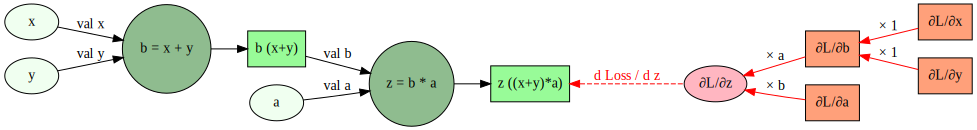

In [ ]:
import graphviz

# 단순 연산의 순/역전파 계산 그래프
dot_simple_bp = graphviz.Digraph(comment='Simple Forward/Backward Propagation')

dot_simple_bp.attr(rankdir='LR') # Left to Right layout for forward pass

# --- 순전파 노드 --- (초록색)
dot_simple_bp.node('x', 'x', shape='ellipse', style='filled', fillcolor='honeydew')
dot_simple_bp.node('y', 'y', shape='ellipse', style='filled', fillcolor='honeydew')
dot_simple_bp.node('a', 'a', shape='ellipse', style='filled', fillcolor='honeydew')

dot_simple_bp.node('add_op', 'b = x + y', shape='circle', style='filled', fillcolor='darkseagreen')
dot_simple_bp.node('mul_op', 'z = b * a', shape='circle', style='filled', fillcolor='darkseagreen')

dot_simple_bp.node('b_val', 'b (x+y)', shape='box', style='filled', fillcolor='palegreen')
dot_simple_bp.node('z_val', 'z ((x+y)*a)', shape='box', style='filled', fillcolor='palegreen')

# 순전파 연결 (초록색)
dot_simple_bp.edge('x', 'add_op', label='val x')
dot_simple_bp.edge('y', 'add_op', label='val y')
dot_simple_bp.edge('add_op', 'b_val')
dot_simple_bp.edge('b_val', 'mul_op', label='val b')
dot_simple_bp.edge('a', 'mul_op', label='val a')
dot_simple_bp.edge('mul_op', 'z_val')

# --- 역전파 노드 --- (빨간색)
dot_simple_bp.node('dL_dz', '∂L/∂z', shape='ellipse', style='filled', fillcolor='lightpink')
dot_simple_bp.node('dL_db', '∂L/∂b', shape='box', style='filled', fillcolor='lightsalmon')
dot_simple_bp.node('dL_da', '∂L/∂a', shape='box', style='filled', fillcolor='lightsalmon')
dot_simple_bp.node('dL_dx', '∂L/∂x', shape='box', style='filled', fillcolor='lightsalmon')
dot_simple_bp.node('dL_dy', '∂L/∂y', shape='box', style='filled', fillcolor='lightsalmon')

# 역전파 연결 (빨간색, 방향 반대)
# z_val -> dL_dz (conceptually)
dot_simple_bp.edge('z_val', 'dL_dz', dir='back', label='  d Loss / d z  ', color='red', fontcolor='red', style='dashed')

# mul_op backward: dL/dz -> dL/db ( * a ), dL/da ( * b )
dot_simple_bp.edge('dL_dz', 'dL_db', label=' × a', dir='back', color='red')
dot_simple_bp.edge('dL_dz', 'dL_da', label=' × b', dir='back', color='red')

# add_op backward: dL/db -> dL/dx ( * 1 ), dL/dy ( * 1 )
dot_simple_bp.edge('dL_db', 'dL_dx', label=' × 1', dir='back', color='red')
dot_simple_bp.edge('dL_db', 'dL_dy', label=' × 1', dir='back', color='red')

# Render the graph
display(dot_simple_bp)

#### 📊 계산 그래프 시각화: 단순 연산의 순/역전파 (014)

아래 그래프는 `z = (x + y) * a`와 같은 단순한 계산 과정에서 순전파(forward propagation)와 역전파(backward propagation)가 어떻게 일어나는지 시각적으로 보여줍니다. 이 그래프를 효과적으로 이해하기 위해 다음 요소들을 주목해주세요.

*   **색상**:
    *   **초록색 계열 (옅은 초록, 진한 초록)**: 순전파(Forward Propagation)와 관련된 요소들을 나타냅니다. 입력값, 연산 노드, 중간 계산 결과 등을 보여줍니다.
    *   **빨간색 계열 (옅은 분홍, 연어색)**: 역전파(Backward Propagation) 및 기울기(Gradient)와 관련된 요소들을 나타냅니다. 최종 손실로부터 역산되는 각 변수의 미분값들을 보여줍니다.

*   **노드 모양**:
    *   **타원 (`ellipse`)**: 주로 입력 변수 (`x`, `y`, `a`)와 최종 손실에 대한 기울기의 시작점 (`∂L/∂z`)과 같이 직접적으로 주어지는 값이나 외부에서 들어오는 값을 나타냅니다.
    *   **원 (`circle`)**: 덧셈 (`add_op`) 또는 곱셈 (`mul_op`)과 같은 연산(Operation)이 일어나는 노드를 나타냅니다. 이 노드에서 순전파 계산이 이루어지고, 역전파 시에는 미분 규칙이 적용됩니다.
    *   **사각형 (`box`)**: 중간 계산 결과 (`b_val`, `z_val`)나 각 변수에 대한 최종 기울기 (`∂L/∂x`, `∂L/∂y`, `∂L/∂a`)를 나타냅니다. 이는 연산 노드를 거쳐 나온 값이나 최종적으로 우리가 얻고자 하는 기울기 값입니다.

*   **화살표 (Edge) 방향 및 라벨**:
    *   **순전파 (→, 초록색)**: 입력에서 출력 방향으로 계산이 진행되는 흐름을 나타냅니다. 라벨은 해당 노드를 통과하는 값 (`val x`, `val y`)을 명시하여, 데이터의 흐름을 이해할 수 있도록 돕습니다.
    *   **역전파 (←, 빨간색)**: 최종 손실(`∂L/∂z`)에서 시작하여 입력 방향으로 거꾸로 거슬러 올라가며 기울기 정보가 전파되는 흐름을 나타냅니다. 라벨은 각 연산 노드의 미분 규칙에 따라 기울기에 곱해지는 값 (`× a`, `× b`, `× 1`)을 명시하며, 이 과정이 바로 **수동 역전파**의 핵심입니다.

*   **순전파**: 입력값 `x`, `y`, `a`가 주어지면, 먼저 덧셈 노드 (`add_op`)를 통해 `x`와 `y`가 더해져 중간값 `b`가 되고, 이 `b`가 `a`와 곱셈 노드 (`mul_op`)를 거쳐 최종 출력 `z`가 계산되는 흐름입니다. 이 과정은 초록색 노드와 화살표로 표현됩니다.

*   **역전파**: 최종 출력 `z`에 대한 손실(Loss)의 미분값(`∂L/∂z`)으로부터 시작하여, 각 연산 노드의 미분 규칙을 따라 거꾸로 거슬러 올라가면서 각 입력 변수(`x`, `y`, `a`)에 대한 미분값(`∂L/∂x`, `∂L/∂y`, `∂L/∂a`)이 계산되는 흐름입니다. 이 과정은 빨간색 노드와 역방향 화살표로 표현됩니다. 특히, 곱셈 노드에서는 상대방의 순전파 값을 곱하고, 덧셈 노드에서는 1을 곱하여 상류의 기울기를 그대로 전달하는 것을 그래프의 빨간색 라벨을 통해 확인할 수 있습니다. 이는 복잡한 신경망에서 각 가중치의 기울기를 효율적으로 계산하는 기본 원리이자, 이 그래프가 보여주는 '수동 전개'의 핵심입니다.



*   **수학적/코드 구조**:
레이어 객체를 쓰지 않고 하나의 함수 안에서 `np.dot`과 활성화 함수 미분을 직접 하드코딩한 형태입니다. 역전파의 첫 단추인 출력 오차 `dy = (y - t) / batch_num`를 시작으로, 출력층 가중치 기울기(`W2`, `b2`)를 구한 뒤, 전치행렬 곱과 시그모이드 미분(`sigmoid_grad`)을 거쳐 입력층 가중치 기울기(`W1`, `b1`)까지 수동으로 역추적합니다.
*   **생활 비유**:
“모듈화된 자동 컨베이어 벨트를 쓰지 않고, 공장장이 작업대에 직접 앉아 수학 공식 문서를 보며 오차 배분 연산을 처음부터 끝까지 한 땀 한 땀 수동으로 계산하는 방식.”
*   **딥러닝 연결**:
구조화된 레이어(Affine, Sigmoid 등) 내부에서 일어나는 행렬 미분 흐름의 원형을 가감 없이 보여주며, Softmax-with-Loss층에서 시작된 오차가 전치행렬 곱 연산을 타고 어떻게 앞 층까지 막힘없이 흘러 들어가는지 직관적으로 증명하는 유용한 뼈대 코드입니다.

#### 🦍 딥러닝에서의 역할 (1):
심플 버전의 역전파 수동 전개는 딥러닝 프레임워크의 도움 없이, 행렬 연산과 미분 공식을 직접 사용하여 각 계층의 기울기를 계산하는 방식입니다. 이는 역전파의 내부 동작 원리를 깊이 이해하는 데 도움을 줍니다.

#### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리 레시피가 너무 복잡해서 자동 조리기구로는 만들 수 없을 때, 셰프가 모든 재료의 양과 조리 시간을 종이에 직접 적어가며 '이 단계에서 맛이 왜 이랬지? 다음엔 얼마큼 바꿔야 하지?' 하고 하나하나 수작업으로 계산하고 수정하는 것과 같아요.

#### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
컴퓨터 프로그램이 고장 났을 때, 프로그램의 모든 코드 라인을 처음부터 끝까지 직접 따라가 보면서 '어떤 줄에서 오류가 발생했는지'를 수동으로 찾아내고 수정하는 디버깅 과정과 같습니다. 비록 번거롭지만, 프로그램의 작동 원리를 가장 정확하게 이해할 수 있습니다.

#### 🧮 파이썬으로 공식을 확인하는 쉬운 예시: 심플 버전 역전파 수동 전개 (014)

자동화된 프레임워크 없이, 간단한 함수에서 오차를 직접 계산하고 역전파를 '수동으로' 구현해볼게요. `y = (x * W) + b` 같은 간단한 모델을 예로 들어봅니다.

In [ ]:
# 가상의 모델: y = x * W + b
# 입력 x, 가중치 W, 편향 b

# 1. 순전파 단계
x = 2
W = 3
b = 1
target_y = 9 # 실제 정답

predicted_y = (x * W) + b # 모델의 예측값
print(f"순전파: x={x}, W={W}, b={b} -> 예측 y={predicted_y}")

# 2. 오차(Loss) 계산 (예: 평균 제곱 오차)
error = predicted_y - target_y # 예측과 정답의 차이
loss = error**2 / 2 # 오차를 제곱하여 양수로 만들고, 2로 나누어 미분 시 계산 편리하게 함
print(f"오차: {error}, 손실: {loss}")

# 3. 역전파 단계 (손실을 줄이기 위해 W와 b를 어떻게 조절할까?)
# d_loss / d_predicted_y = error (손실을 predicted_y로 미분)
d_predicted_y = error

# d_predicted_y / d_b = 1 (predicted_y = xW + b를 b로 미분)
d_b = d_predicted_y * 1

# d_predicted_y / d_W = x (predicted_y = xW + b를 W로 미분)
d_W = d_predicted_y * x

# d_predicted_y / d_x = W (predicted_y = xW + b를 x로 미분)
d_x = d_predicted_y * W

print(f"\n역전파 (W와 b를 조절하기 위한 피드백):")
print(f"  b에 대한 기울기 (db): {d_b:.2f}")
print(f"  W에 대한 기울기 (dW): {d_W:.2f}")
print(f"  x에 대한 기울기 (dx): {d_x:.2f}")

print("-> 손실(loss)이 가장 크게 줄어드는 방향으로 가중치(W)와 편향(b)을 얼마나 조절해야 하는지 수동으로 계산했습니다.")

순전파: x=2, W=3, b=1 -> 예측 y=7
오차: -2, 손실: 2.0

역전파 (W와 b를 조절하기 위한 피드백):
  b에 대한 기울기 (db): -2.00
  W에 대한 기울기 (dW): -4.00
  x에 대한 기울기 (dx): -6.00
-> 손실(loss)이 가장 크게 줄어드는 방향으로 가중치(W)와 편향(b)을 얼마나 조절해야 하는지 수동으로 계산했습니다.


#### 💡 확인 문제: 014. 심플 버전의 역전파 수동 전개

Q1. 딥러닝 프레임워크의 도움 없이, 행렬 연산과 미분 공식을 직접 사용하여 각 계층의 기울기를 계산하는 방식을 무엇이라고 할 수 있나요?

Q2. 이 방법은 딥러닝의 어떤 원리를 깊이 이해하는 데 도움을 주나요?

Q3. `y = x * W + b`와 같은 간단한 모델에서, 손실(loss)이 가장 크게 줄어드는 방향으로 가중치(W)와 편향(b)을 얼마나 조절해야 하는지를 직접 손으로 계산하는 것은 무엇을 확인하는 과정인가요?

✅ **정답**

Q1. 수동 역전파 (Manual Backpropagation) 또는 밑바닥부터 구현 (From Scratch Implementation)

Q2. 역전파의 내부 동작 원리 (또는 미분 흐름의 원형)

Q3. 손실에 대한 가중치와 편향의 기울기 (gradient)를 확인하는 과정입니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>
<br/>




#### 🚀 핵심 개념 최종 정리

**01. 계산 그래프의 순전파 (Forward Propagation in Computation Graph)**
*   **핵심**: 입력 데이터가 여러 계산 단계를 거쳐 최종 결과(예측값)를 만들어내는 과정. 마치 레시피를 앞에서부터 순서대로 따라 요리하는 것과 같아요.
*   **딥러닝에서**: 이미지가 신경망의 여러 층을 통과하며 '이것이 고양이인지 강아지인지' 최종 판단을 내리는 과정이에요.

**02. 덧셈 노드의 역전파 (Backward Propagation for Addition)**
*   **핵심**: 계산 결과에 대한 피드백(오차)이 덧셈이 일어난 곳으로 돌아갈 때, 그 피드백이 입력값들에게 변함없이 똑같이 전달되는 방식.
*   **딥러닝에서**: 여러 정보가 더해진 곳에서 모델이 '잘못됐다'는 피드백을 받으면, 이 피드백이 더해진 각 정보에 같은 크기로 전달되어 다음 번에는 더 나은 예측을 하도록 돕는 과정이에요.

**03. 곱셈 노드의 역전파 (Backward Propagation for Multiplication)**
*   **핵심**: 계산 결과에 대한 피드백(오차)이 곱셈이 일어난 곳으로 돌아갈 때, 피드백이 서로의 원래 값에 비례하여 전달되는 방식.
*   **딥러닝에서**: 데이터와 가중치가 곱해진 곳에서 모델이 '잘못됐다'는 피드백을 받으면, 피드백이 각 데이터와 가중치에 서로의 값에 따라 다르게 전달되어 더욱 정교하게 학습해요.

**04. 배치용 Affine 계층의 편미분 (Gradient for Batch Affine Layer)**
*   **핵심**: 여러 데이터를 한 묶음(배치)으로 처리하는 계산에서, 피드백(기울기)이 행렬 계산의 규칙에 따라 효율적으로 역추적되어 각 입력과 가중치에 전달되는 방식.
*   **딥러닝에서**: 많은 양의 이미지를 동시에 처리할 때, '이 이미지를 고양이로 잘못 판단했네?'라는 피드백이 오면, 이 피드백이 수많은 이미지와 가중치에 대해 한 번에 계산되어 모델을 더 빠르게 똑똑하게 만들어요.

**05. ReLU 계층 구현 (Python Implementation of ReLU Layer)**
*   **핵심**: 입력 값이 0보다 작거나 같으면 0으로 만들고, 0보다 크면 그대로 통과시키는 필터 같은 역할. 마치 나쁜 재료는 버리고 좋은 재료만 쓰는 것과 같아요.
*   **딥러닝에서**: 신경망에서 불필요한 정보(음수 값)를 걸러내고 중요한 정보(양수 값)만 다음 단계로 보내서, 모델이 더 똑똑해지고 계산도 빨라지도록 돕는 스위치 같은 기능이에요.

**06. 시그모이드 계층 구현 (Python Implementation of Sigmoid Layer)**
*   **핵심**: 어떤 숫자든 0과 1 사이의 확률 값으로 바꿔주는 함수. '이것일 확률은 0.8'처럼요.
*   **딥러닝에서**: 모델이 '고양이일 확률이 70%'와 같이 최종 예측을 확률로 표현할 때 사용해요. 예측이 틀렸을 때, 이 확률값만으로도 모델을 어떻게 고쳐야 할지(피드백) 쉽게 알 수 있어요.

**07. Softmax with Loss 계층 (Python Implementation of Softmax with Loss Layer)**
*   **핵심**: 여러 가지 가능성 중에서 각각의 확률을 계산하고(Softmax), 동시에 실제 정답과 얼마나 다른지 벌점(Loss)을 매기는 기능.
*   **딥러닝에서**: 모델이 '고양이일 확률, 강아지일 확률, 새일 확률'을 모두 계산하고, 그 예측이 실제 정답과 얼마나 차이가 나는지 벌점을 줘서 모델이 학습하도록 해요.

**08. 교차 엔트로피 오차 함수 (Python Implementation of Cross Entropy Error)**
*   **핵심**: 모델의 예측이 실제 정답과 얼마나 다른지 벌점을 매기는 방법. 특히, '강하게 잘못 예측했을 때' 더 큰 벌점을 줘서 정신 차리게 하는 거예요.
*   **딥러닝에서**: 모델이 '이건 100% 고양이다!'라고 강하게 예측했는데 실제로는 강아지였다면, 아주 큰 벌점을 줘서 모델이 다음 번에는 더 신중하고 정확하게 예측하도록 학습시켜요.

**09. Affine 계층 구현 (Python Implementation of Affine Layer)**
*   **핵심**: 입력 데이터에 가중치를 곱하고 편향을 더하는 기본적인 계산. 데이터를 다음 단계에 필요한 새로운 형태로 변환해요.
*   **딥러닝에서**: 신경망의 핵심 계산 블록으로, 들어온 정보를 중요한 것 위주로 곱하고(가중치), 기본값을 더해서(편향) 다음 층으로 전달할 새로운 정보로 만들어요.

**10. 2층 신경망 구조 정의 (Two-Layer Network Architecture Definition)**
*   **핵심**: 두 개의 층(은닉층, 출력층)으로 구성된 가장 기본적인 신경망 설계도. 각 층에 어떤 계산 도구(Affine, ReLU, Softmax 등)를 배치할지 정하는 거예요.
*   **딥러닝에서**: '재료 손질 -> 조리 -> 플레이팅'처럼, 데이터가 들어와서 최종 결과가 나오기까지의 전체 계산 과정을 순서대로 설계하고 연결하는 모델의 큰 그림이에요.

**11. 예측, 손실, 정확도 구현 (Network Methods for Prediction, Loss, and Accuracy)**
*   **핵심**: 모델이 얼마나 잘 작동하는지 확인하는 세 가지 중요한 평가 방법. '예측하기', '오차 계산하기', '정확도 측정하기'.
*   **딥러닝에서**: 모델이 새로운 데이터를 얼마나 잘 예측하는지, 예측이 얼마나 틀렸는지 벌점을 매기고, 전체 예측 중 몇 개를 맞췄는지 점수를 매겨 모델의 실력을 평가하고 개선해요.

**12. 케라스를 이용한 신경망 구현 (High-Level Deep Learning Implementation with Keras)**
*   **핵심**: 복잡한 신경망 코딩을 마치 레고 블록 조립하듯이 쉽고 간단하게 할 수 있도록 도와주는 도구.
*   **딥러닝에서**: 딥러닝 모델을 만들 때, 복잡한 수학 계산이나 코드를 직접 할 필요 없이 '이런 층 추가!', '이렇게 학습시켜!'라고 명령만 내리면 모델을 뚝딱 만들 수 있게 해주는 편리한 프레임워크예요.

**13. 역전파 기반의 gradient 메서드 구현 (Efficient Gradient Computation via Backpropagation)**
*   **핵심**: 최종 결과의 오차를 가지고 레시피의 마지막 단계부터 거꾸로 되짚어가며, 각 재료와 과정 중 어떤 것이 문제였고 얼마나 조절해야 하는지 효율적으로 찾아내는 방법.
*   **딥러닝에서**: 모델이 예측을 틀렸을 때, 이 '틀린 정도'를 가지고 신경망의 모든 가중치와 편향을 얼마나 바꿔야 할지 가장 빠르고 정확하게 계산하는 핵심 학습 방법이에요.

**14. 심플 버전의 역전파 수동 전개 (Flat/Simple Manual Backpropagation Implementation)**
*   **핵심**: 복잡한 도구 없이, 오차가 발생했을 때 이 오차가 각 재료에 얼마나 영향을 주었는지를 맨 처음 재료까지 직접 손으로 역추적하며 계산해 보는 방법.
*   **딥러닝에서**: 역전파가 어떻게 작동하는지 가장 근본적인 원리를 이해하기 위해, 자동화된 프레임워크 없이 수학 공식 그대로 각 단계의 기울기를 직접 계산해 보는 연습 같은 거예요.